In [1]:
from scipy.stats import randint, uniform
import sys
from pathlib import Path

# Go up one level to project root
project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root))

from src.utils.tune_hyperparameters import ModelTuner, PipelineTuner
filename = r"../../data/raw/ACME-HappinessSurvey2020.csv"


# model
from sklearn.ensemble import RandomForestClassifier

e:\dev\workspace\Apziva\Project1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
random_state = 0

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV 1/5; 1/100] START bootstrap=True, max_depth=2, n_estimators=17..............
[CV 1/5; 1/100] END bootstrap=True, max_depth=2, n_estimators=17;, score=(train=0.700, test=0.500) total time=   0.0s
[CV 2/5; 1/100] START bootstrap=True, max_depth=2, n_estimators=17..............
[CV 2/5; 1/100] END bootstrap=True, max_depth=2, n_estimators=17;, score=(train=0.613, test=0.650) total time=   0.0s
[CV 3/5; 1/100] START bootstrap=True, max_depth=2, n_estimators=17..............
[CV 3/5; 1/100] END bootstrap=True, max_depth=2, n_estimators=17;, score=(train=0.775, test=0.500) total time=   0.0s
[CV 4/5; 1/100] START bootstrap=True, max_depth=2, n_estimators=17..............
[CV 4/5; 1/100] END bootstrap=True, max_depth=2, n_estimators=17;, score=(train=0.738, test=0.600) total time=   0.0s
[CV 5/5; 1/100] START bootstrap=True, max_depth=2, n_estimators=17..............
[CV 5/5; 1/100] END bootstrap=True, max_depth=2, n_estimator

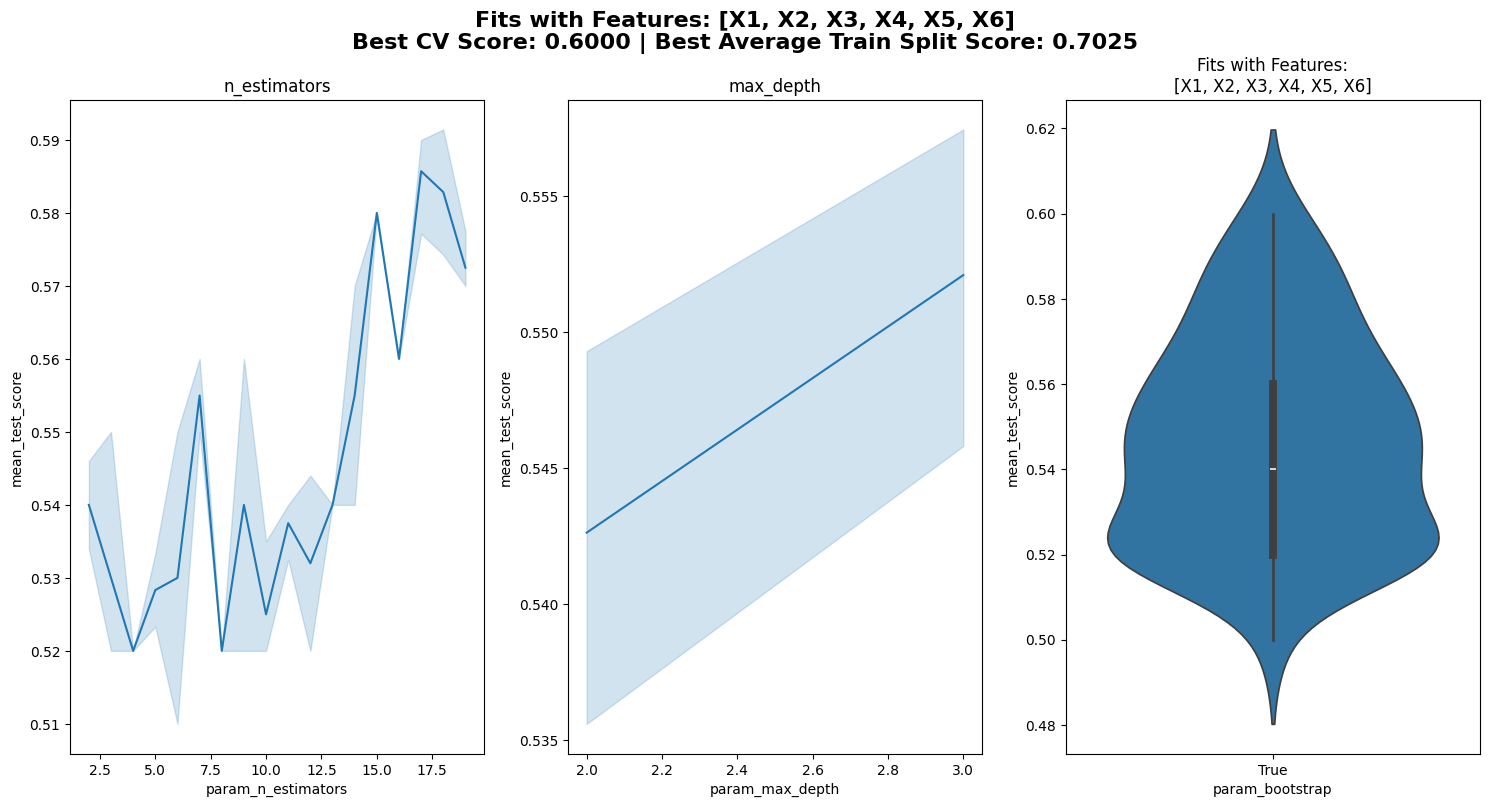



Feature Permutation Importance
______________________
X1: 0.092 +/- 0.071
X5: 0.069 +/- 0.051
X6: 0.058 +/- 0.031
X2: 0.046 +/- 0.057
X3: 0.015 +/- 0.043
X4: 0.012 +/- 0.018

______________________


e:\dev\workspace\Apziva\Project1\src\utils\tune_hyperparameters.py:292: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, i], X_test_subset, show=False)


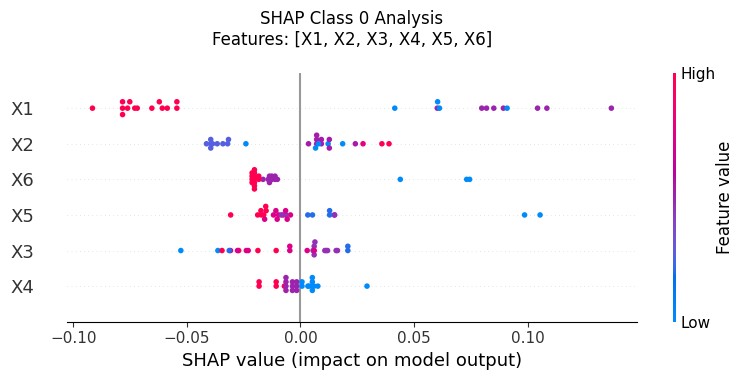

e:\dev\workspace\Apziva\Project1\src\utils\tune_hyperparameters.py:292: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, i], X_test_subset, show=False)


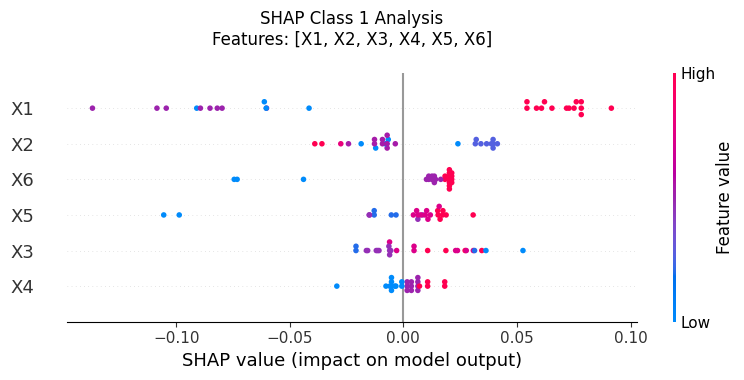

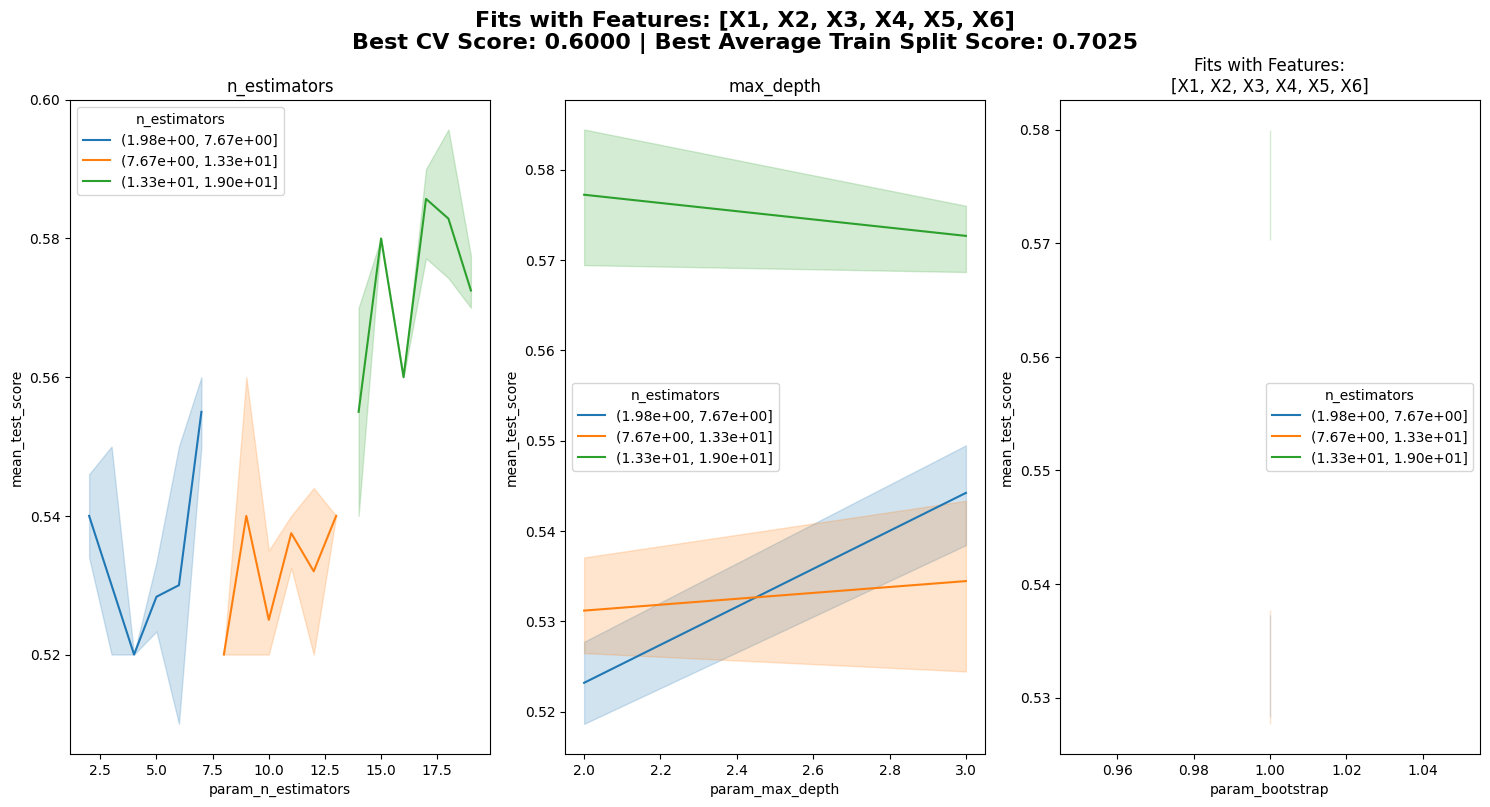

In [3]:
parameter_grid = {
    "n_estimators": randint(2, 20),
    "max_depth": randint(2,4),
    # "min_samples_split": randint(2, 21),
    # "min_samples_leaf": randint(1, 21),
    # "max_features": ["sqrt", "log2", None],
    # "min_weight_fraction_leaf": uniform(0.0, 0.5),
    "bootstrap": [True],
}

model = RandomForestClassifier(random_state = random_state)
categorical_features = ["X1","X2","X3","X4","X5","X6"]

t = ModelTuner(model, filename, "Y", categorical_features, random_state = random_state)

search = t.tune_model(hyperParameterGrid=parameter_grid, n_iter = 100,)
t.feature_permutation(search.best_params_)
t.shap_analysis(search.best_params_)
t.display_parameter_fits(search, parameter_grid, groupby="n_estimators")

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV 1/5; 1/100] START bootstrap=True, max_depth=2, n_estimators=17..............
[CV 1/5; 1/100] END bootstrap=True, max_depth=2, n_estimators=17;, score=(train=0.713, test=0.550) total time=   0.0s
[CV 2/5; 1/100] START bootstrap=True, max_depth=2, n_estimators=17..............
[CV 2/5; 1/100] END bootstrap=True, max_depth=2, n_estimators=17;, score=(train=0.713, test=0.700) total time=   0.0s
[CV 3/5; 1/100] START bootstrap=True, max_depth=2, n_estimators=17..............
[CV 3/5; 1/100] END bootstrap=True, max_depth=2, n_estimators=17;, score=(train=0.750, test=0.500) total time=   0.0s
[CV 4/5; 1/100] START bootstrap=True, max_depth=2, n_estimators=17..............
[CV 4/5; 1/100] END bootstrap=True, max_depth=2, n_estimators=17;, score=(train=0.713, test=0.650) total time=   0.0s
[CV 5/5; 1/100] START bootstrap=True, max_depth=2, n_estimators=17..............
[CV 5/5; 1/100] END bootstrap=True, max_depth=2, n_estimator

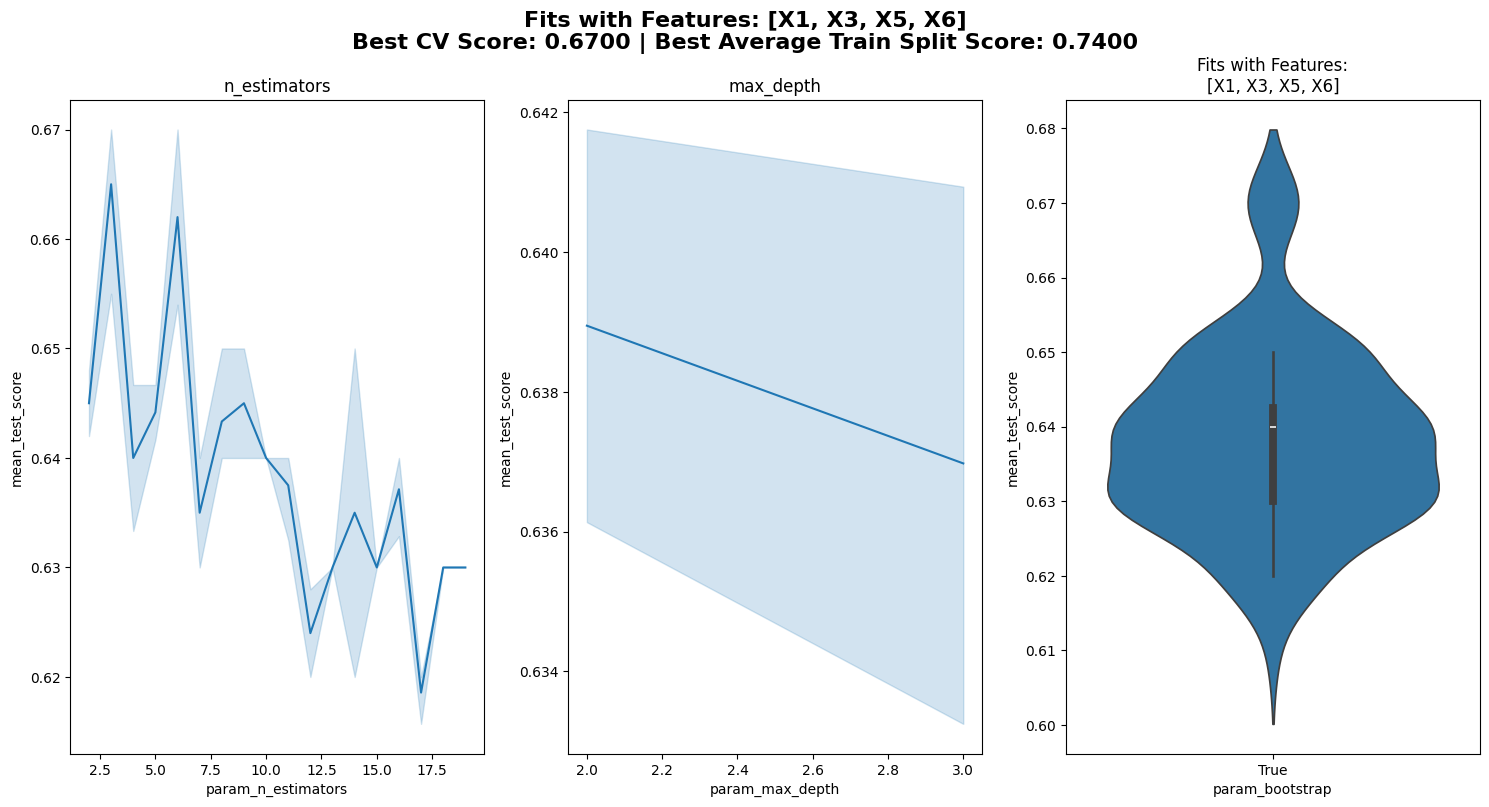



Feature Permutation Importance
______________________
X5: 0.081 +/- 0.056
X1: 0.065 +/- 0.086
X6: -0.004 +/- 0.036
X3: -0.042 +/- 0.027

______________________


e:\dev\workspace\Apziva\Project1\src\utils\tune_hyperparameters.py:292: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, i], X_test_subset, show=False)


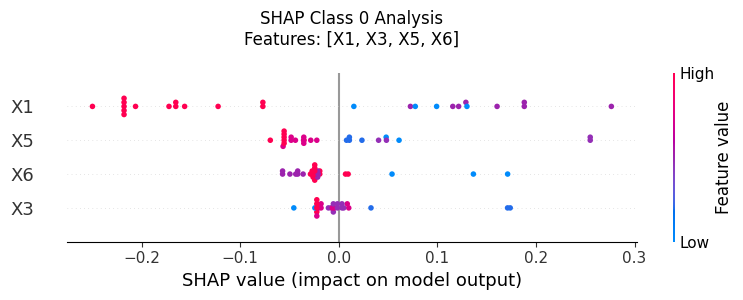

e:\dev\workspace\Apziva\Project1\src\utils\tune_hyperparameters.py:292: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, i], X_test_subset, show=False)


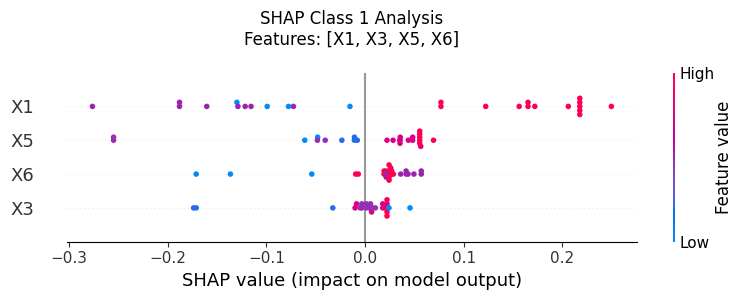

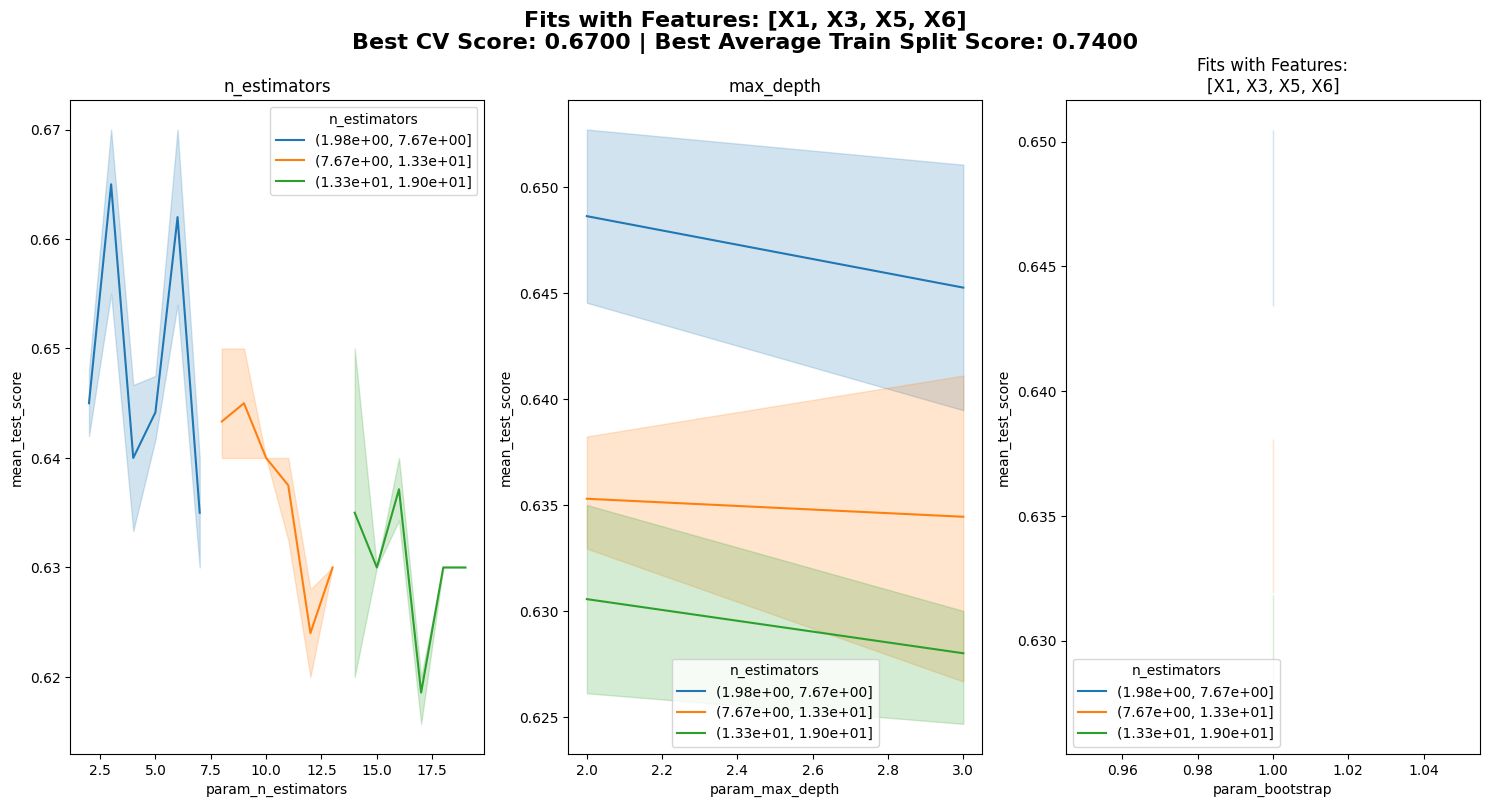

In [4]:
parameter_grid = {
    "n_estimators": randint(2, 20),
    "max_depth": randint(2,4),
    # "min_samples_split": randint(2, 21),
    # "min_samples_leaf": randint(1, 21),
    # "max_features": ["sqrt", "log2", None],
    # "min_weight_fraction_leaf": uniform(0.0, 0.5),
    "bootstrap": [True],
}

model = RandomForestClassifier(random_state = random_state)
categorical_features = ["X1","X3","X5","X6"]

t = ModelTuner(model, filename, "Y", categorical_features, random_state = random_state)

search = t.tune_model(hyperParameterGrid=parameter_grid, n_iter = 100,)
t.feature_permutation(search.best_params_)
t.shap_analysis(search.best_params_)
t.display_parameter_fits(search, parameter_grid, groupby="n_estimators")

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV 1/5; 1/100] START bootstrap=True, max_depth=2, n_estimators=17..............
[CV 1/5; 1/100] END bootstrap=True, max_depth=2, n_estimators=17;, score=(train=0.713, test=0.450) total time=   0.0s
[CV 2/5; 1/100] START bootstrap=True, max_depth=2, n_estimators=17..............
[CV 2/5; 1/100] END bootstrap=True, max_depth=2, n_estimators=17;, score=(train=0.625, test=0.700) total time=   0.0s
[CV 3/5; 1/100] START bootstrap=True, max_depth=2, n_estimators=17..............
[CV 3/5; 1/100] END bootstrap=True, max_depth=2, n_estimators=17;, score=(train=0.725, test=0.500) total time=   0.0s
[CV 4/5; 1/100] START bootstrap=True, max_depth=2, n_estimators=17..............
[CV 4/5; 1/100] END bootstrap=True, max_depth=2, n_estimators=17;, score=(train=0.637, test=0.650) total time=   0.0s
[CV 5/5; 1/100] START bootstrap=True, max_depth=2, n_estimators=17..............
[CV 5/5; 1/100] END bootstrap=True, max_depth=2, n_estimator

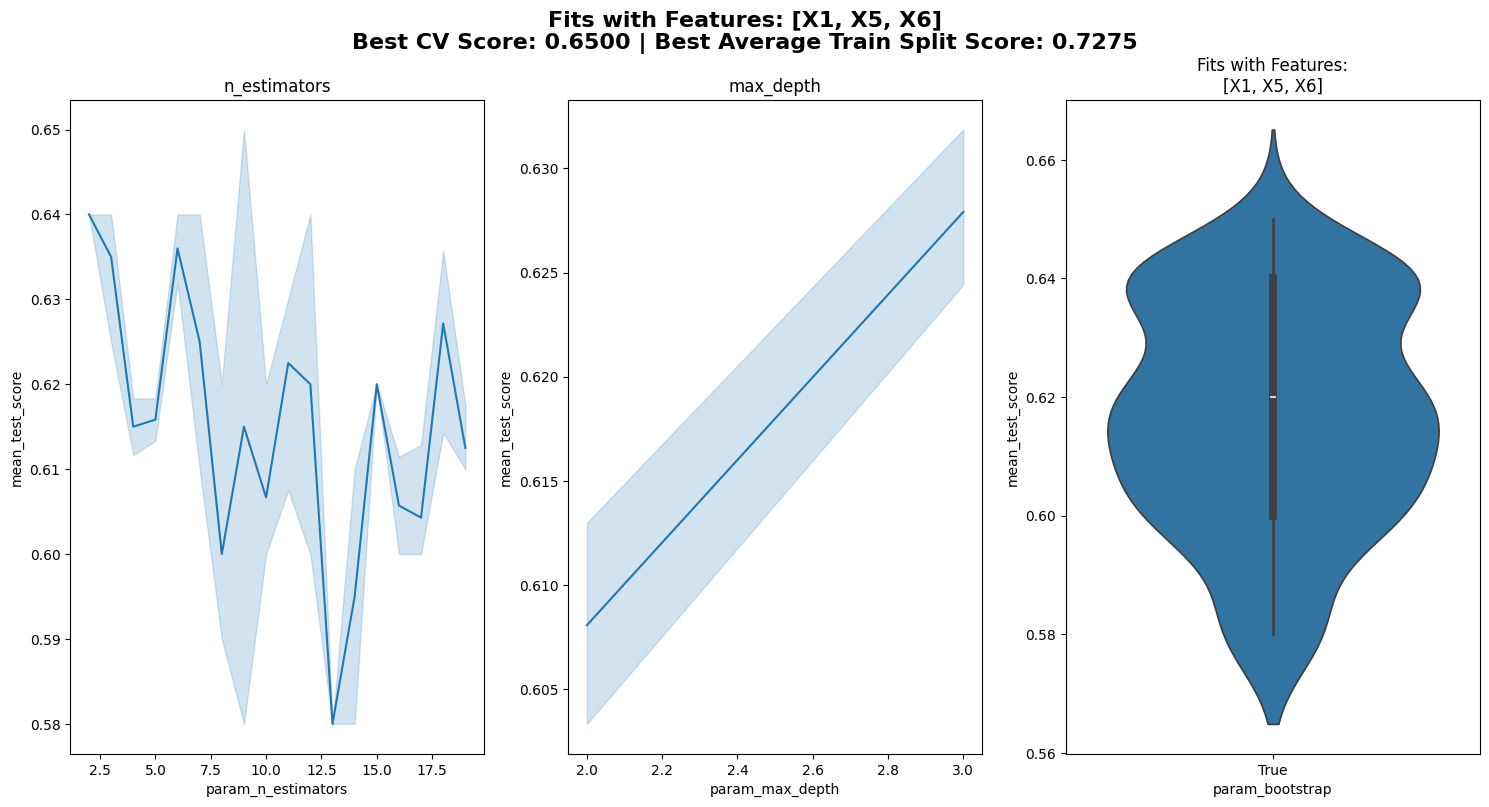



Feature Permutation Importance
______________________
X5: 0.127 +/- 0.122
X1: 0.123 +/- 0.062
X6: 0.085 +/- 0.073

______________________


e:\dev\workspace\Apziva\Project1\src\utils\tune_hyperparameters.py:292: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, i], X_test_subset, show=False)


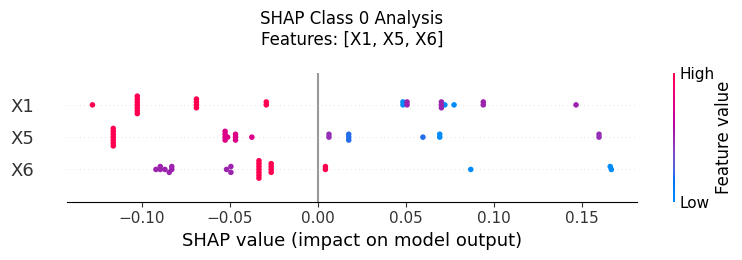

e:\dev\workspace\Apziva\Project1\src\utils\tune_hyperparameters.py:292: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, i], X_test_subset, show=False)


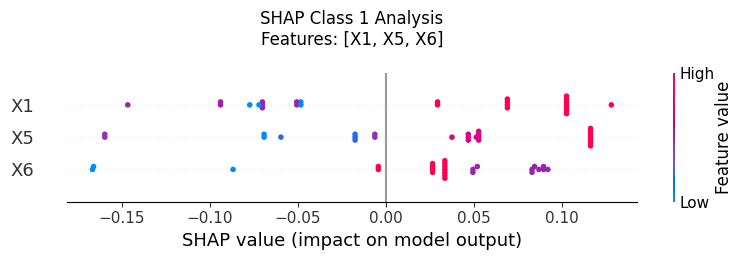

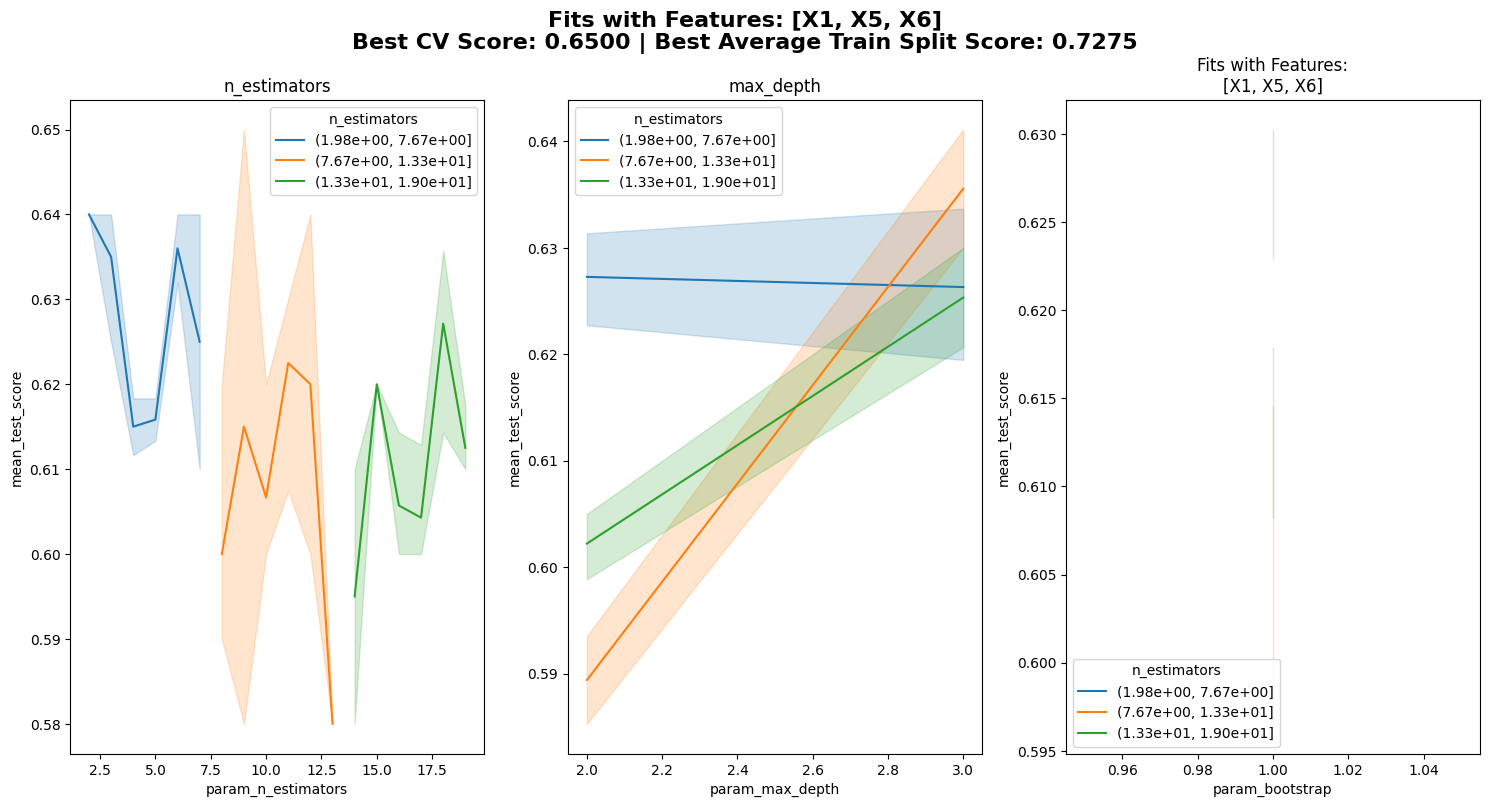

In [5]:
parameter_grid = {
    "n_estimators": randint(2, 20),
    "max_depth": randint(2,4),
    # "min_samples_split": randint(2, 21),
    # "min_samples_leaf": randint(1, 21),
    # "max_features": ["sqrt", "log2", None],
    # "min_weight_fraction_leaf": uniform(0.0, 0.5),
    "bootstrap": [True],
}

model = RandomForestClassifier(random_state = random_state)
categorical_features = ["X1","X5","X6"]

t = ModelTuner(model, filename, "Y", categorical_features, random_state = random_state)

search = t.tune_model(hyperParameterGrid=parameter_grid, n_iter = 100,)
t.feature_permutation(search.best_params_)
t.shap_analysis(search.best_params_)
t.display_parameter_fits(search, parameter_grid, groupby="n_estimators")

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV 1/5; 1/100] START bootstrap=True, max_depth=2, n_estimators=17..............
[CV 1/5; 1/100] END bootstrap=True, max_depth=2, n_estimators=17;, score=(train=0.713, test=0.550) total time=   0.0s
[CV 2/5; 1/100] START bootstrap=True, max_depth=2, n_estimators=17..............
[CV 2/5; 1/100] END bootstrap=True, max_depth=2, n_estimators=17;, score=(train=0.637, test=0.750) total time=   0.0s
[CV 3/5; 1/100] START bootstrap=True, max_depth=2, n_estimators=17..............
[CV 3/5; 1/100] END bootstrap=True, max_depth=2, n_estimators=17;, score=(train=0.738, test=0.500) total time=   0.0s
[CV 4/5; 1/100] START bootstrap=True, max_depth=2, n_estimators=17..............
[CV 4/5; 1/100] END bootstrap=True, max_depth=2, n_estimators=17;, score=(train=0.675, test=0.700) total time=   0.0s
[CV 5/5; 1/100] START bootstrap=True, max_depth=2, n_estimators=17..............
[CV 5/5; 1/100] END bootstrap=True, max_depth=2, n_estimator

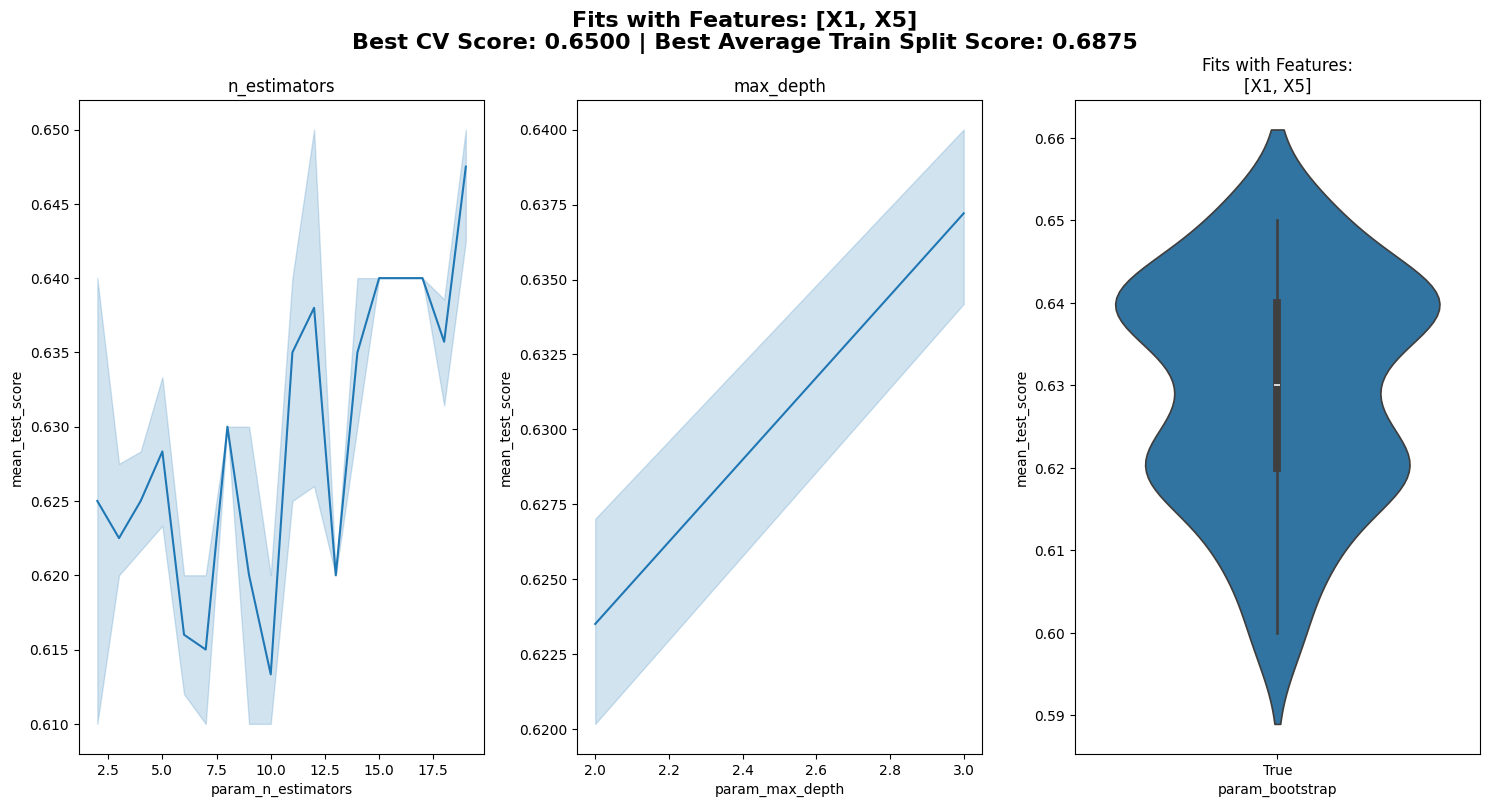



Feature Permutation Importance
______________________
X5: 0.173 +/- 0.093
X1: 0.088 +/- 0.097

______________________


e:\dev\workspace\Apziva\Project1\src\utils\tune_hyperparameters.py:292: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, i], X_test_subset, show=False)


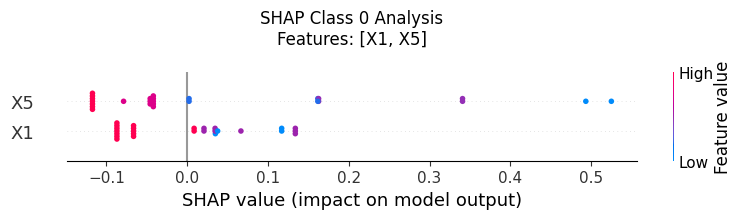

e:\dev\workspace\Apziva\Project1\src\utils\tune_hyperparameters.py:292: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, i], X_test_subset, show=False)


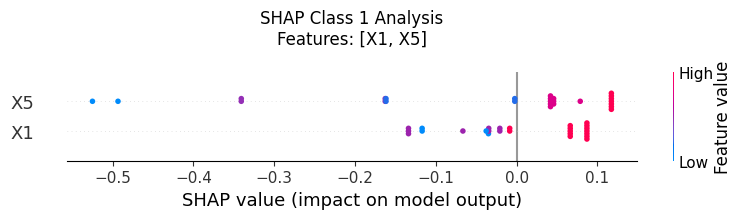

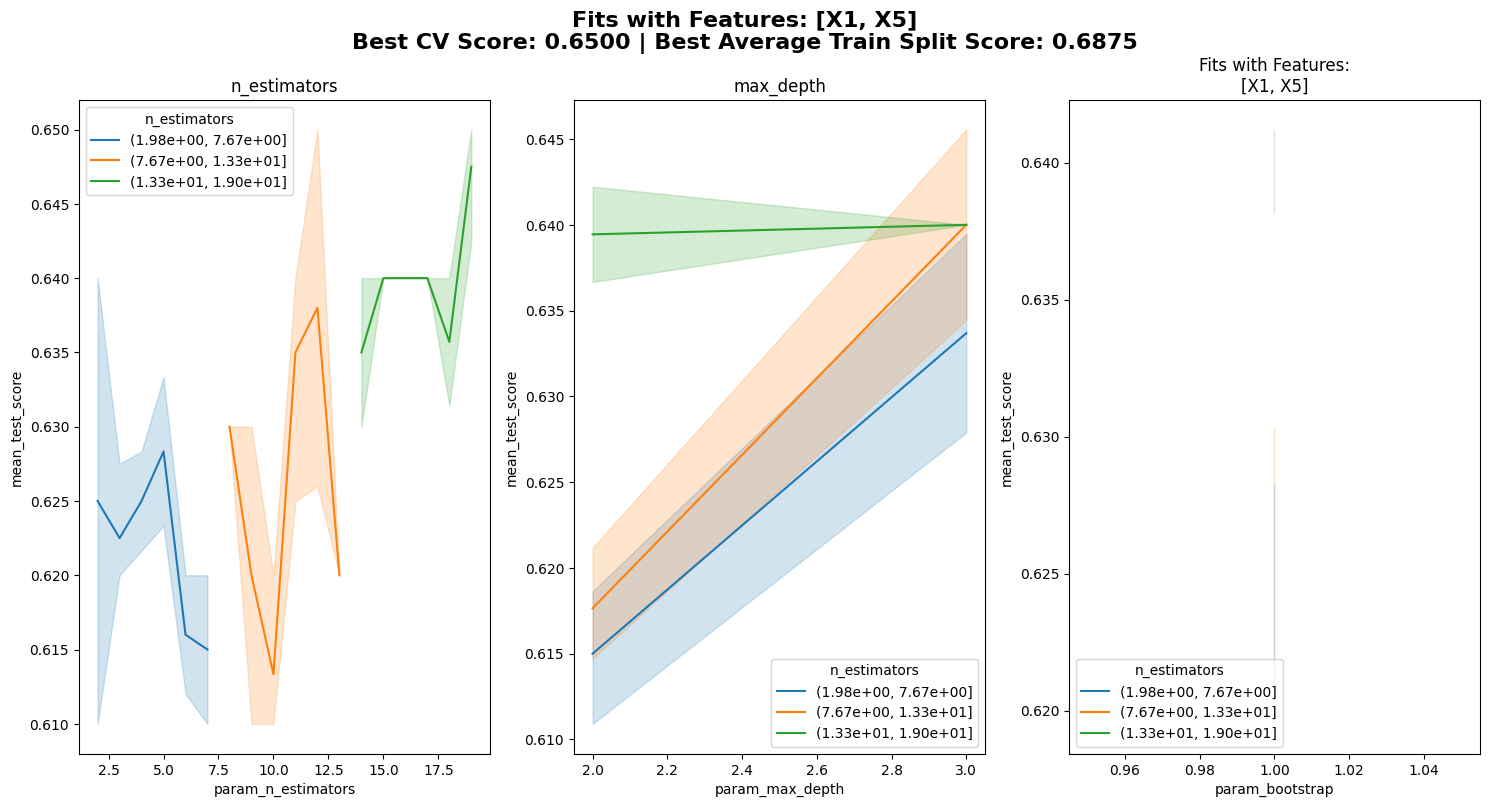

In [6]:
parameter_grid = {
    "n_estimators": randint(2, 20),
    "max_depth": randint(2,4),
    # "min_samples_split": randint(2, 21),
    # "min_samples_leaf": randint(1, 21),
    # "max_features": ["sqrt", "log2", None],
    # "min_weight_fraction_leaf": uniform(0.0, 0.5),
    "bootstrap": [True],
}

model = RandomForestClassifier(random_state = random_state)
categorical_features = ["X1","X5"]

t = ModelTuner(model, filename, "Y", categorical_features, random_state = random_state)

search = t.tune_model(hyperParameterGrid=parameter_grid, n_iter = 100,)
t.feature_permutation(search.best_params_)
t.shap_analysis(search.best_params_)
t.display_parameter_fits(search, parameter_grid, groupby="n_estimators")

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV 1/5; 1/100] START bootstrap=True, max_depth=2, n_estimators=17..............
[CV 1/5; 1/100] END bootstrap=True, max_depth=2, n_estimators=17;, score=(train=0.713, test=0.500) total time=   0.0s
[CV 2/5; 1/100] START bootstrap=True, max_depth=2, n_estimators=17..............
[CV 2/5; 1/100] END bootstrap=True, max_depth=2, n_estimators=17;, score=(train=0.662, test=0.850) total time=   0.0s
[CV 3/5; 1/100] START bootstrap=True, max_depth=2, n_estimators=17..............
[CV 3/5; 1/100] END bootstrap=True, max_depth=2, n_estimators=17;, score=(train=0.725, test=0.500) total time=   0.0s
[CV 4/5; 1/100] START bootstrap=True, max_depth=2, n_estimators=17..............
[CV 4/5; 1/100] END bootstrap=True, max_depth=2, n_estimators=17;, score=(train=0.713, test=0.650) total time=   0.0s
[CV 5/5; 1/100] START bootstrap=True, max_depth=2, n_estimators=17..............
[CV 5/5; 1/100] END bootstrap=True, max_depth=2, n_estimator

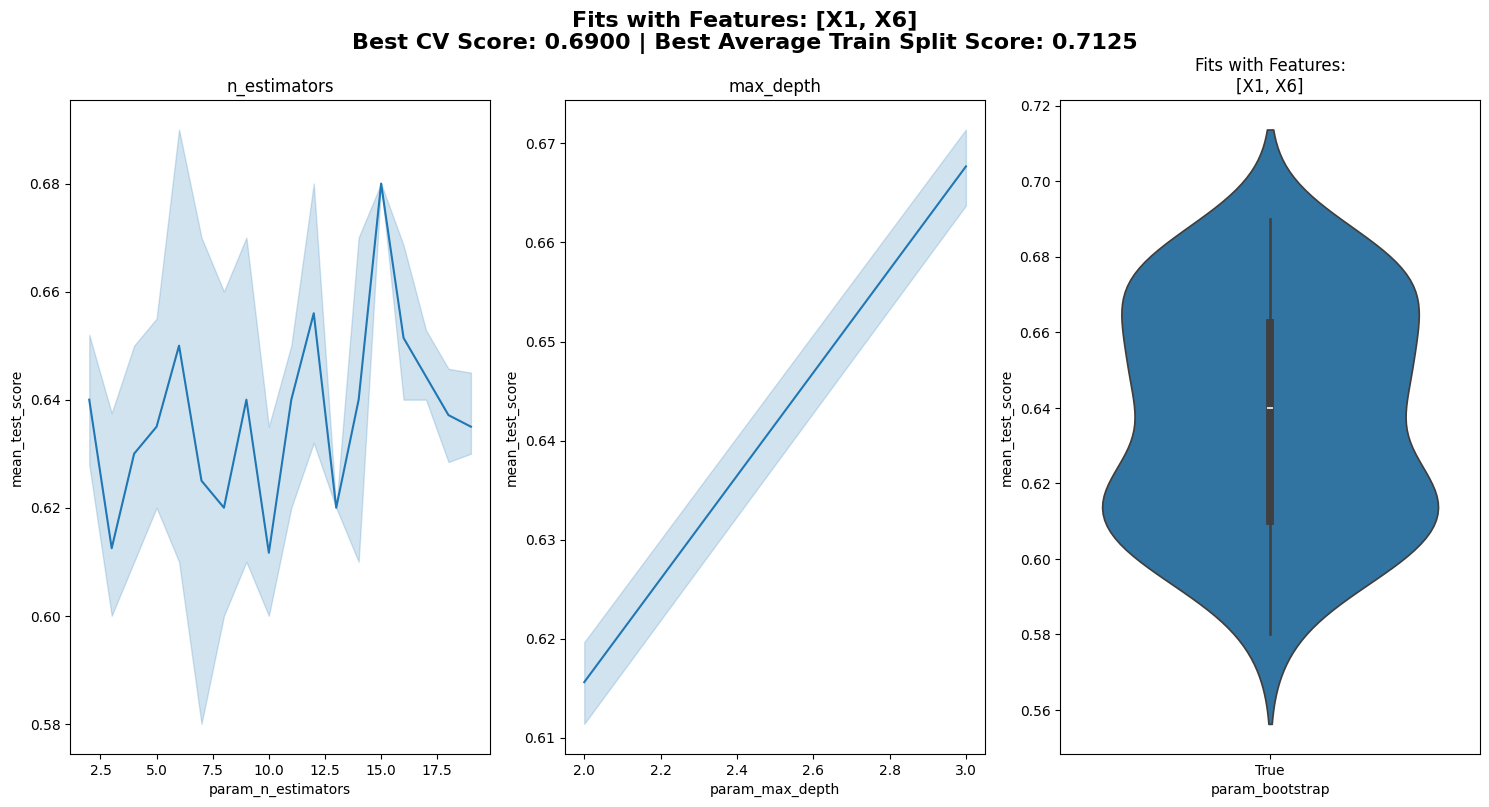



Feature Permutation Importance
______________________
X1: 0.046 +/- 0.104
X6: 0.035 +/- 0.044

______________________


e:\dev\workspace\Apziva\Project1\src\utils\tune_hyperparameters.py:292: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, i], X_test_subset, show=False)


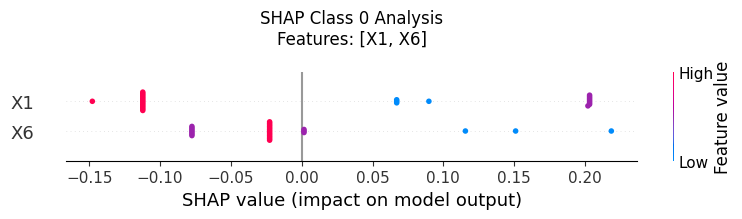

e:\dev\workspace\Apziva\Project1\src\utils\tune_hyperparameters.py:292: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, i], X_test_subset, show=False)


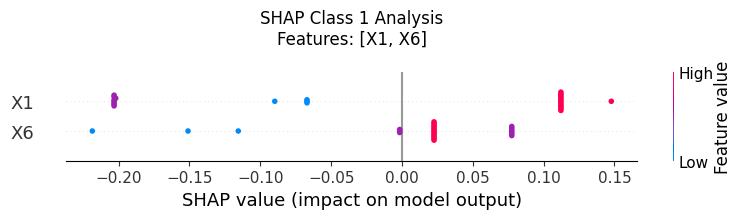

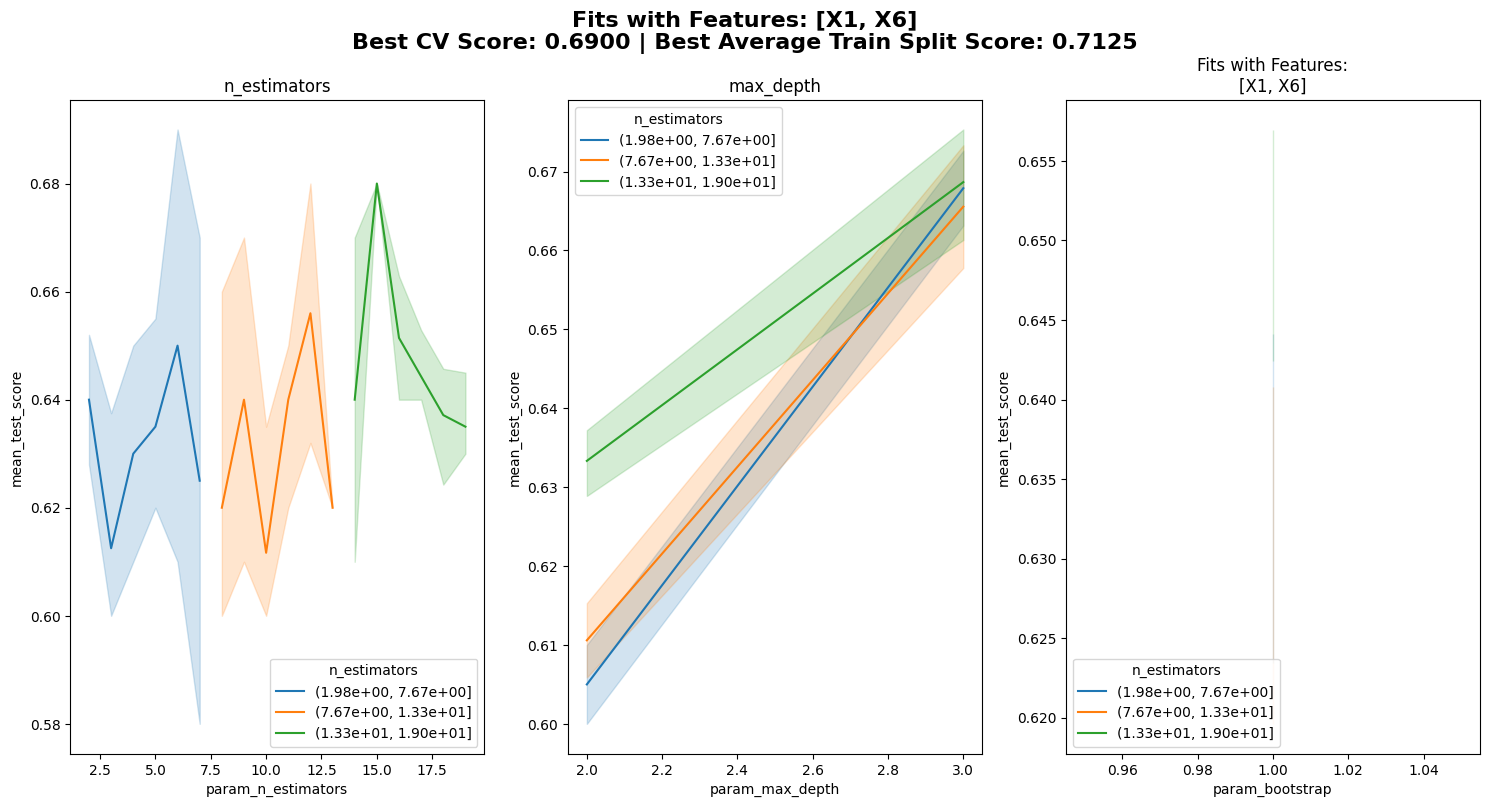

In [7]:
parameter_grid = {
    "n_estimators": randint(2, 20),
    "max_depth": randint(2,4),
    # "min_samples_split": randint(2, 21),
    # "min_samples_leaf": randint(1, 21),
    # "max_features": ["sqrt", "log2", None],
    # "min_weight_fraction_leaf": uniform(0.0, 0.5),
    "bootstrap": [True],
}

model = RandomForestClassifier(random_state = random_state)
categorical_features = ["X1","X6"]

t = ModelTuner(model, filename, "Y", categorical_features, random_state = random_state)

search = t.tune_model(hyperParameterGrid=parameter_grid, n_iter = 100,)
t.feature_permutation(search.best_params_)
t.shap_analysis(search.best_params_)
t.display_parameter_fits(search, parameter_grid, groupby="n_estimators")

In [8]:
t.predict_test_split(search.best_params_)

0.5384615384615384

In [9]:
random_state += 1

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV 1/5; 1/100] START bootstrap=True, max_depth=3, n_estimators=13..............
[CV 1/5; 1/100] END bootstrap=True, max_depth=3, n_estimators=13;, score=(train=0.713, test=0.600) total time=   0.0s
[CV 2/5; 1/100] START bootstrap=True, max_depth=3, n_estimators=13..............
[CV 2/5; 1/100] END bootstrap=True, max_depth=3, n_estimators=13;, score=(train=0.713, test=0.500) total time=   0.0s
[CV 3/5; 1/100] START bootstrap=True, max_depth=3, n_estimators=13..............
[CV 3/5; 1/100] END bootstrap=True, max_depth=3, n_estimators=13;, score=(train=0.700, test=0.750) total time=   0.0s
[CV 4/5; 1/100] START bootstrap=True, max_depth=3, n_estimators=13..............
[CV 4/5; 1/100] END bootstrap=True, max_depth=3, n_estimators=13;, score=(train=0.713, test=0.600) total time=   0.0s
[CV 5/5; 1/100] START bootstrap=True, max_depth=3, n_estimators=13..............
[CV 5/5; 1/100] END bootstrap=True, max_depth=3, n_estimator

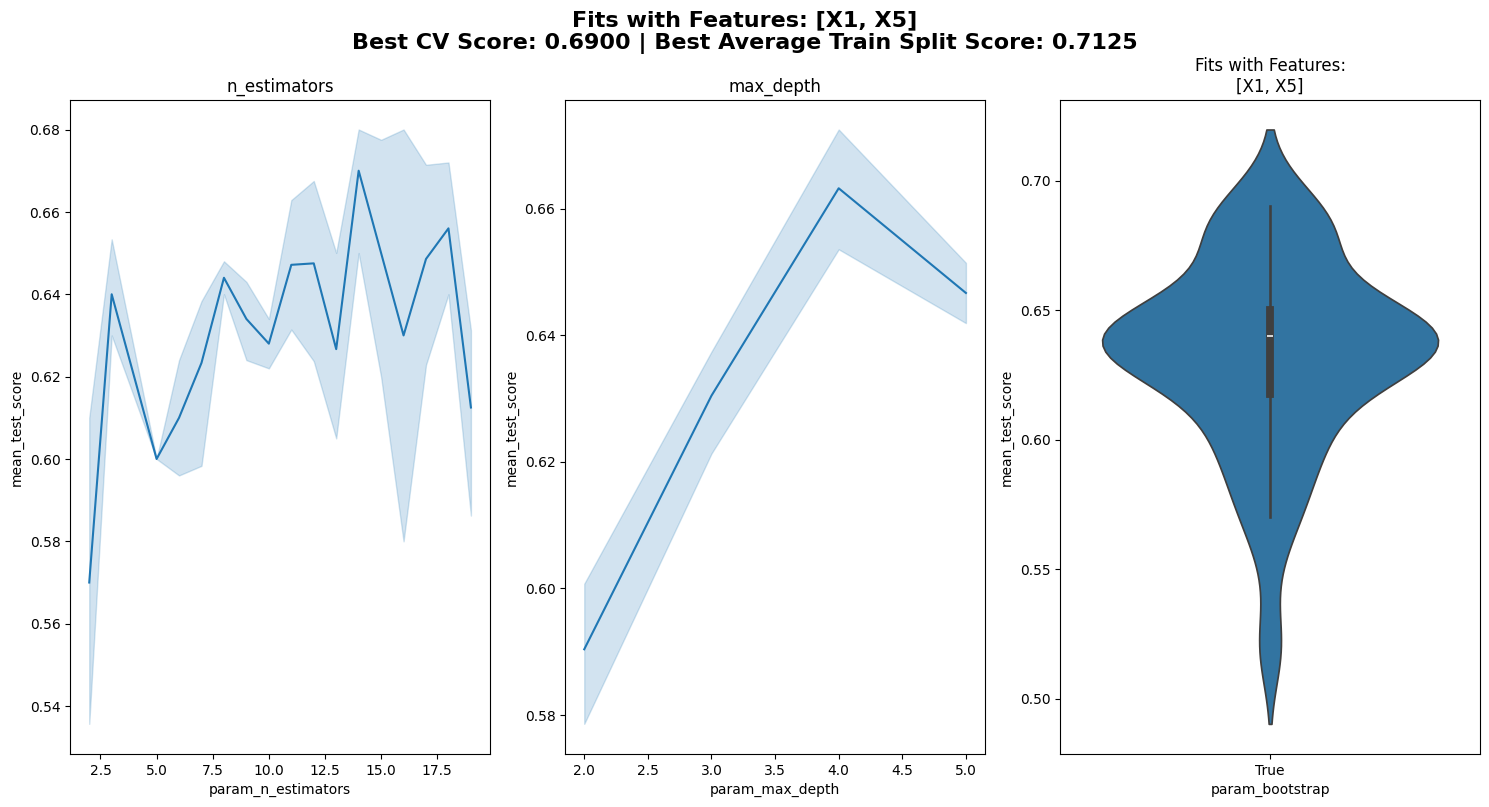



Feature Permutation Importance
______________________
X1: 0.200 +/- 0.091
X5: -0.012 +/- 0.067

______________________


e:\dev\workspace\Apziva\Project1\src\utils\tune_hyperparameters.py:292: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, i], X_test_subset, show=False)


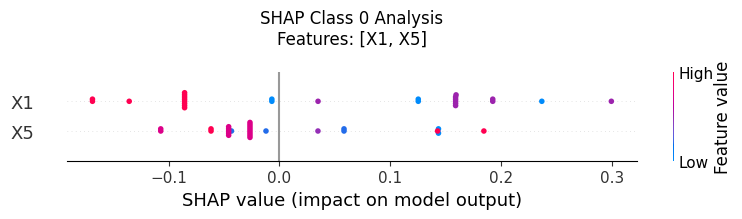

e:\dev\workspace\Apziva\Project1\src\utils\tune_hyperparameters.py:292: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, i], X_test_subset, show=False)


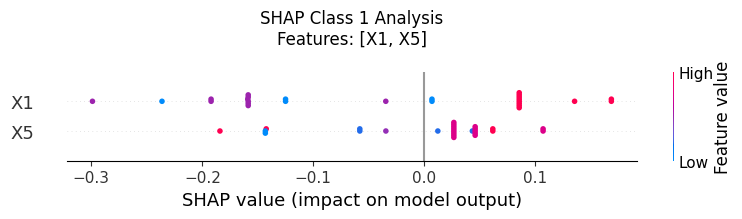

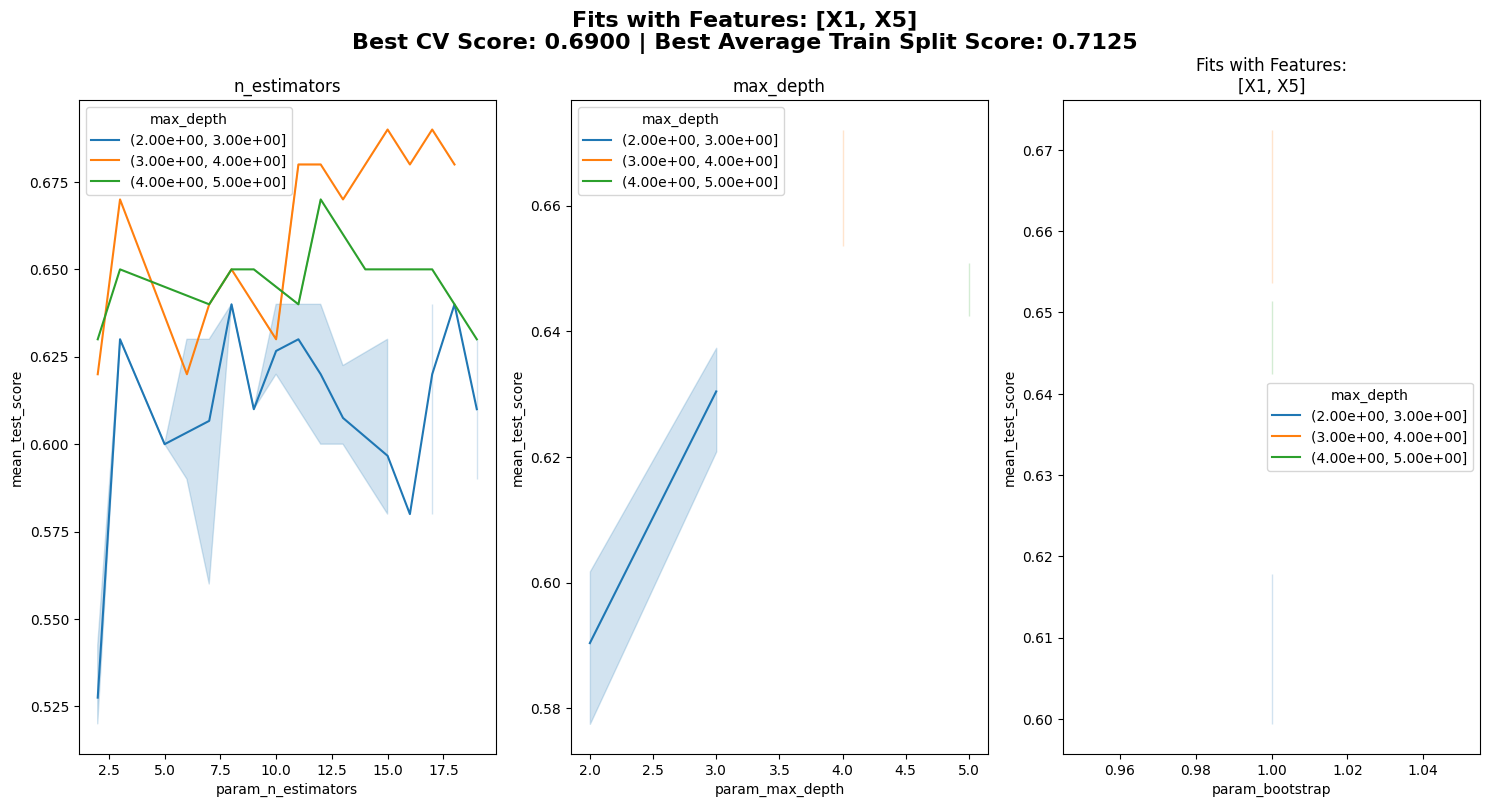

In [10]:
parameter_grid = {
    "n_estimators": randint(2, 20),
    "max_depth": randint(2,6),
    # "min_samples_split": randint(2, 21),
    # "min_samples_leaf": randint(1, 21),
    # "max_features": ["sqrt", "log2", None],
    # "min_weight_fraction_leaf": uniform(0.0, 0.5),
    "bootstrap": [True],
}

model = RandomForestClassifier(random_state = random_state)
categorical_features = ["X1","X5"]

t = ModelTuner(model, filename, "Y", categorical_features, random_state = random_state)

search = t.tune_model(hyperParameterGrid=parameter_grid, n_iter = 100,)
t.feature_permutation(search.best_params_)
t.shap_analysis(search.best_params_)
t.display_parameter_fits(search, parameter_grid, groupby="max_depth")

In [11]:
t.predict_test_split(search.best_params_)

0.6538461538461539

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV 1/5; 1/100] START bootstrap=True, max_depth=3, min_samples_leaf=5, n_estimators=14
[CV 1/5; 1/100] END bootstrap=True, max_depth=3, min_samples_leaf=5, n_estimators=14;, score=(train=0.700, test=0.600) total time=   0.0s
[CV 2/5; 1/100] START bootstrap=True, max_depth=3, min_samples_leaf=5, n_estimators=14
[CV 2/5; 1/100] END bootstrap=True, max_depth=3, min_samples_leaf=5, n_estimators=14;, score=(train=0.738, test=0.500) total time=   0.0s
[CV 3/5; 1/100] START bootstrap=True, max_depth=3, min_samples_leaf=5, n_estimators=14
[CV 3/5; 1/100] END bootstrap=True, max_depth=3, min_samples_leaf=5, n_estimators=14;, score=(train=0.688, test=0.600) total time=   0.0s
[CV 4/5; 1/100] START bootstrap=True, max_depth=3, min_samples_leaf=5, n_estimators=14
[CV 4/5; 1/100] END bootstrap=True, max_depth=3, min_samples_leaf=5, n_estimators=14;, score=(train=0.700, test=0.550) total time=   0.0s
[CV 5/5; 1/100] START bootstrap=True,

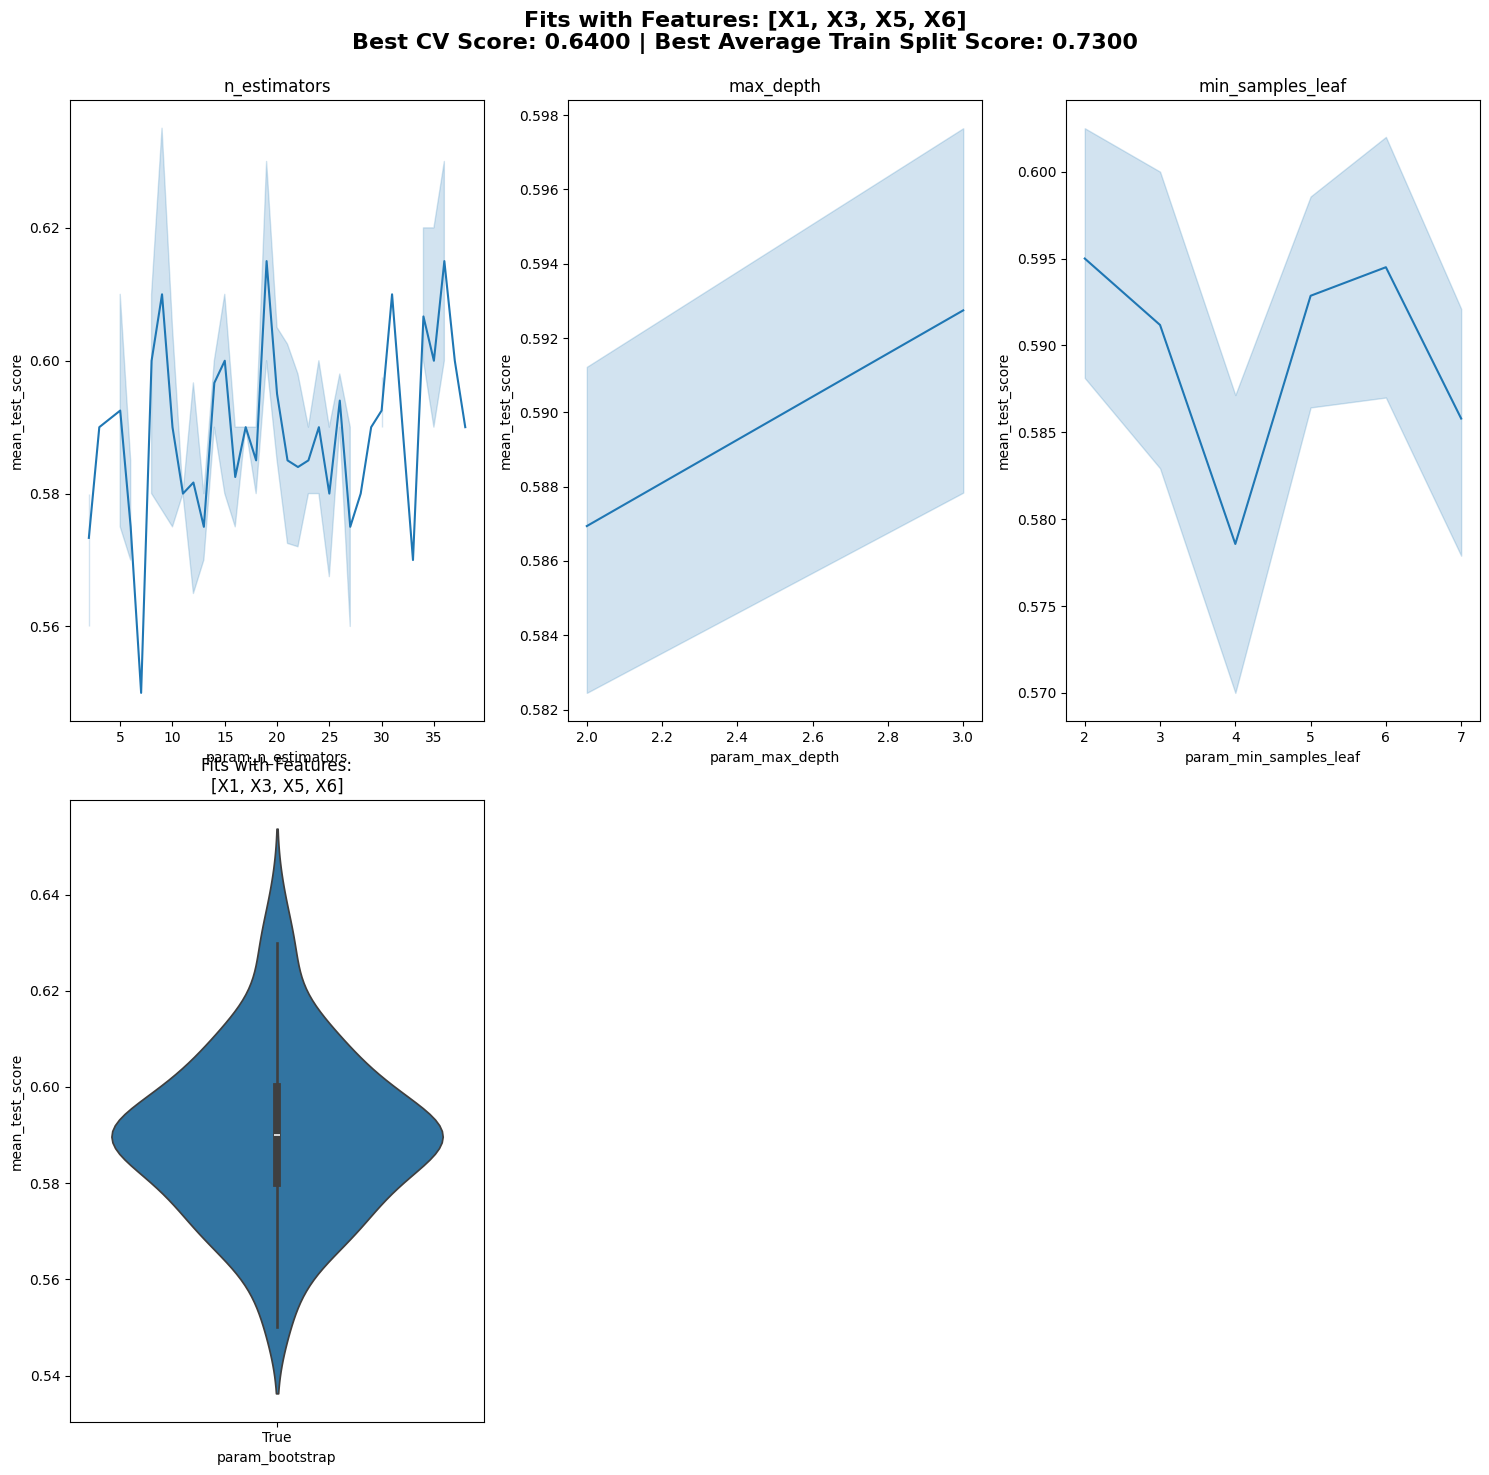



Feature Permutation Importance
______________________
X1: 0.154 +/- 0.073
X5: -0.023 +/- 0.073
X6: -0.031 +/- 0.023
X3: -0.038 +/- 0.069

______________________


e:\dev\workspace\Apziva\Project1\src\utils\tune_hyperparameters.py:292: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, i], X_test_subset, show=False)


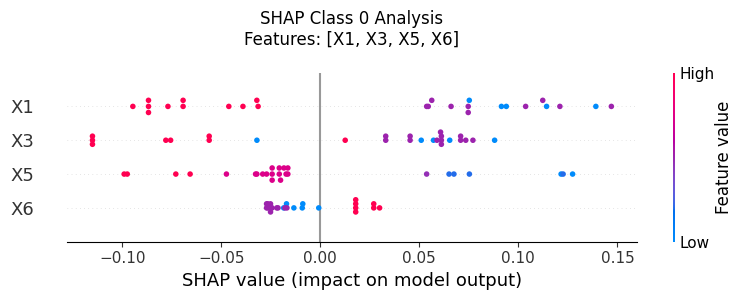

e:\dev\workspace\Apziva\Project1\src\utils\tune_hyperparameters.py:292: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, i], X_test_subset, show=False)


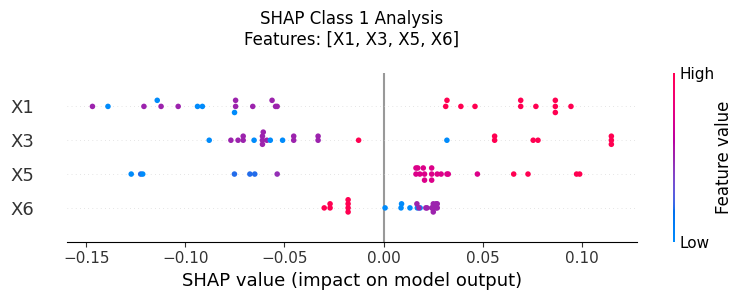

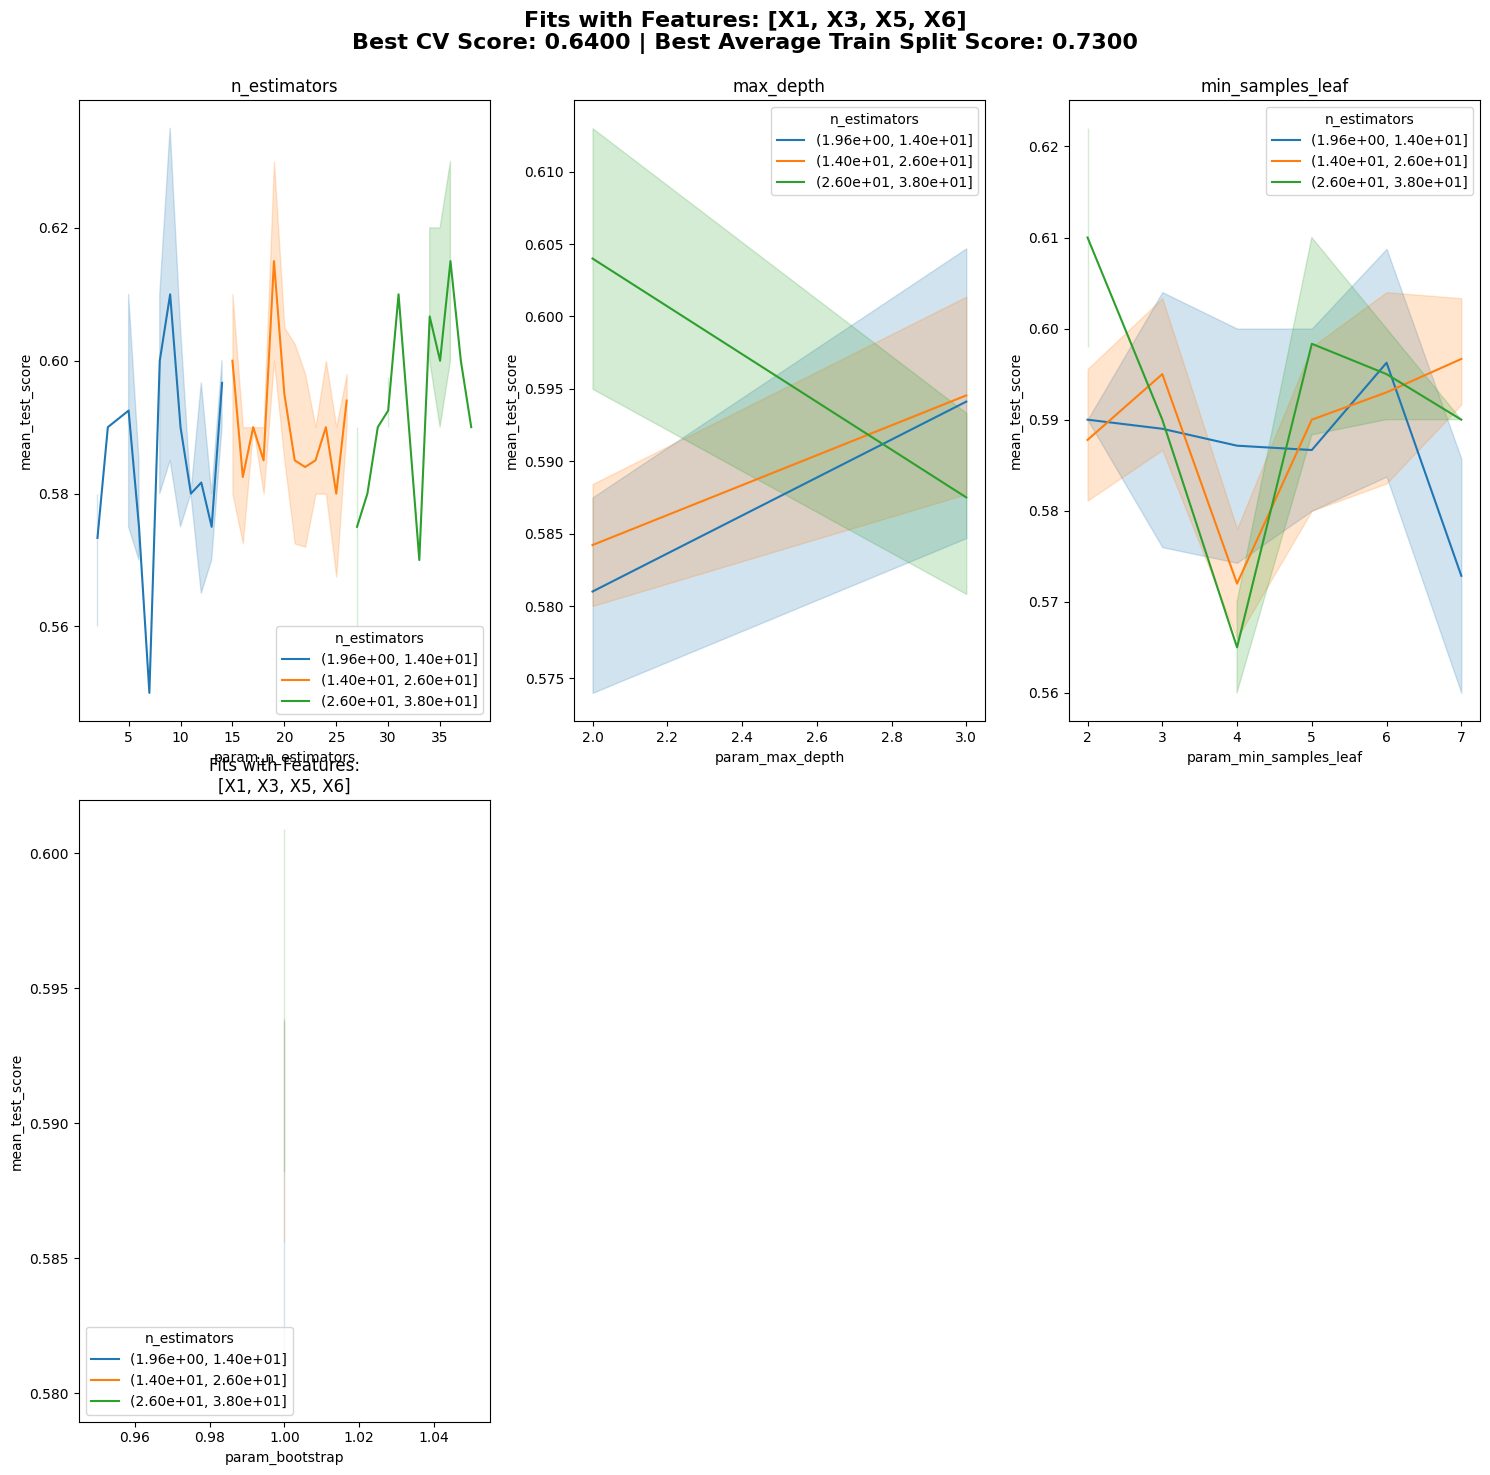

In [12]:
parameter_grid = {
    "n_estimators": randint(2, 40),
    "max_depth": randint(2,4),
    # "min_samples_split": randint(2, 21),
    "min_samples_leaf": randint(2,8),
    # "max_features": ["sqrt", "log2", None],
    # "min_weight_fraction_leaf": uniform(0.0, 0.5),
    "bootstrap": [True],
}

model = RandomForestClassifier(random_state = random_state)
categorical_features = ["X1","X3","X5","X6"]

t = ModelTuner(model, filename, "Y", categorical_features, random_state = random_state)

search = t.tune_model(hyperParameterGrid=parameter_grid, n_iter = 100,)
t.feature_permutation(search.best_params_)
t.shap_analysis(search.best_params_)
t.display_parameter_fits(search, parameter_grid, groupby="n_estimators")

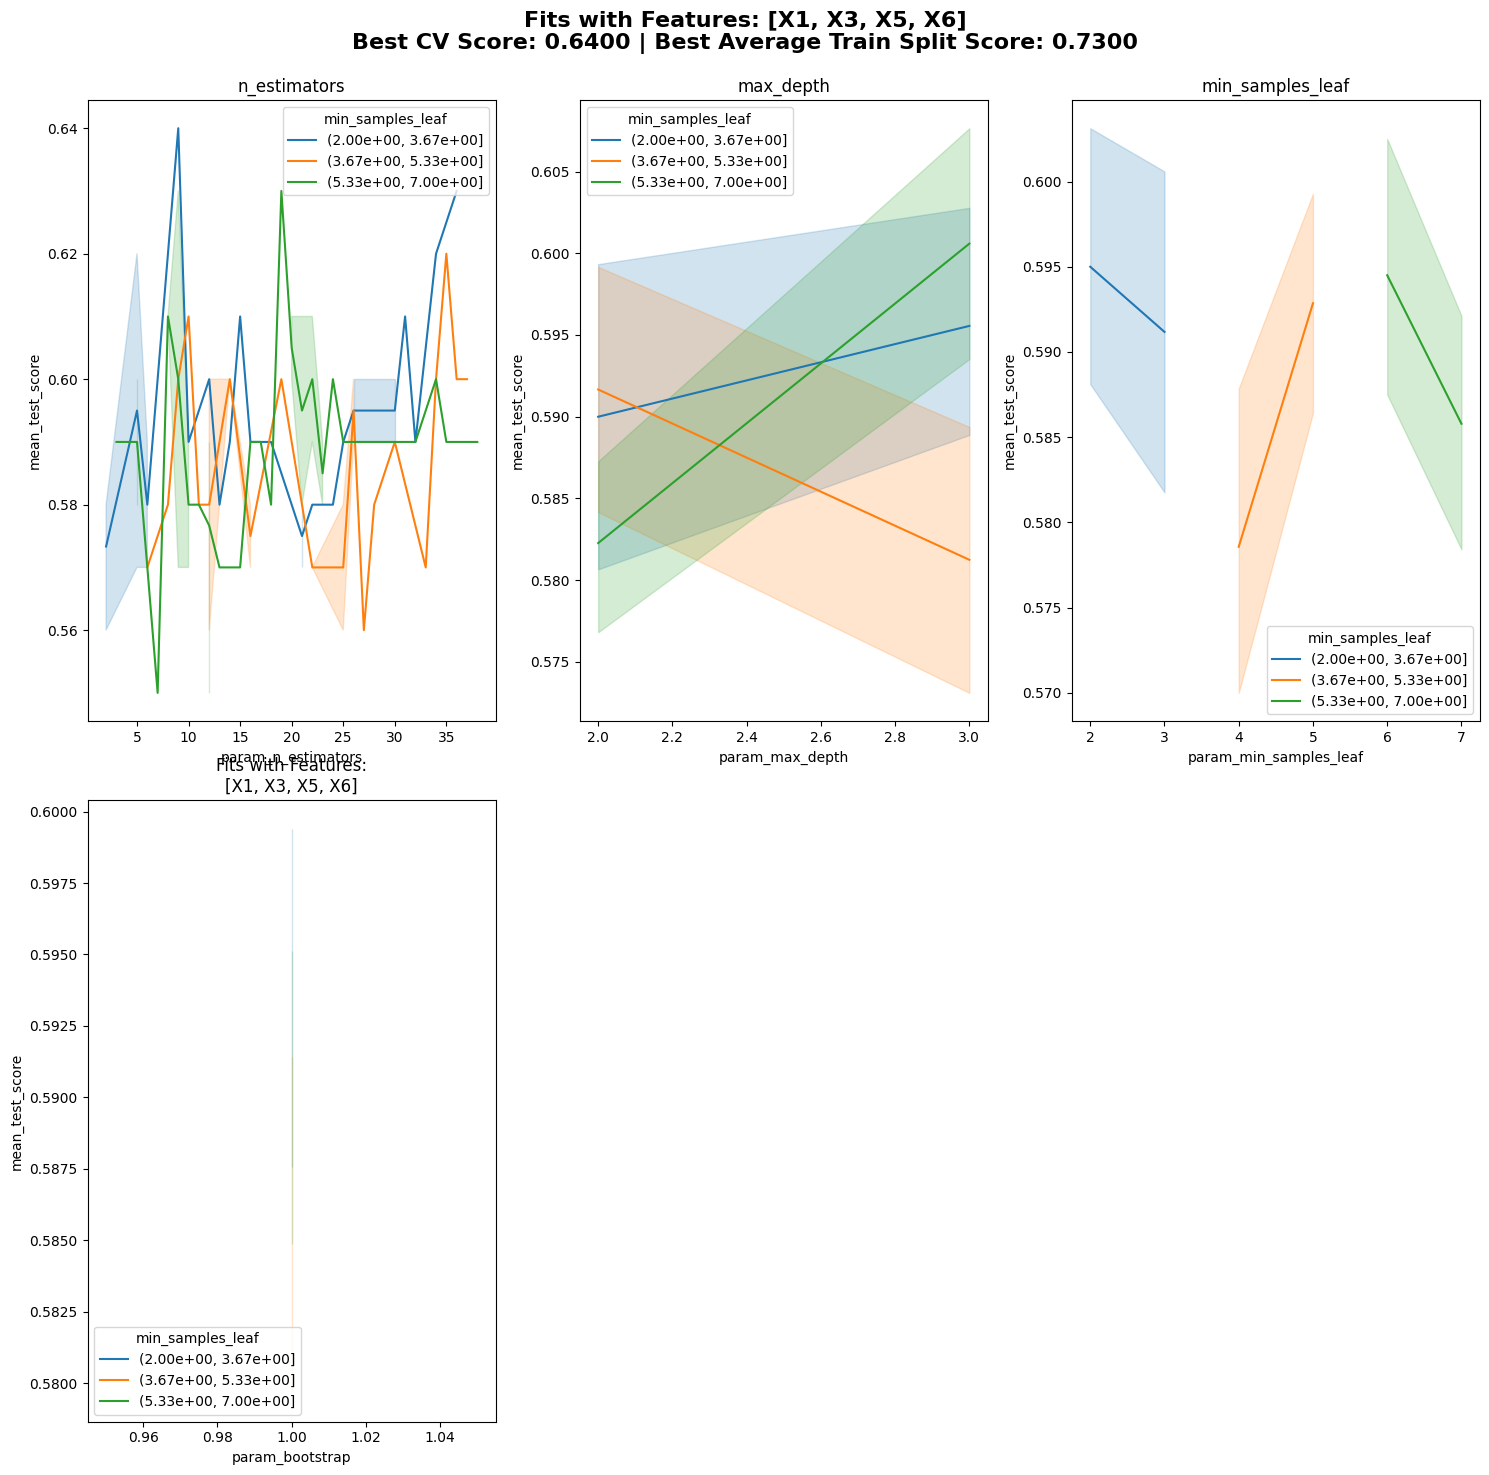

In [13]:
t.display_parameter_fits(search, parameter_grid, groupby="min_samples_leaf")

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV 1/5; 1/100] START bootstrap=True, max_depth=9, min_samples_leaf=5, n_estimators=52
[CV 1/5; 1/100] END bootstrap=True, max_depth=9, min_samples_leaf=5, n_estimators=52;, score=(train=0.688, test=0.600) total time=   0.0s
[CV 2/5; 1/100] START bootstrap=True, max_depth=9, min_samples_leaf=5, n_estimators=52
[CV 2/5; 1/100] END bootstrap=True, max_depth=9, min_samples_leaf=5, n_estimators=52;, score=(train=0.688, test=0.650) total time=   0.0s
[CV 3/5; 1/100] START bootstrap=True, max_depth=9, min_samples_leaf=5, n_estimators=52
[CV 3/5; 1/100] END bootstrap=True, max_depth=9, min_samples_leaf=5, n_estimators=52;, score=(train=0.688, test=0.600) total time=   0.0s
[CV 4/5; 1/100] START bootstrap=True, max_depth=9, min_samples_leaf=5, n_estimators=52
[CV 4/5; 1/100] END bootstrap=True, max_depth=9, min_samples_leaf=5, n_estimators=52;, score=(train=0.700, test=0.600) total time=   0.0s
[CV 5/5; 1/100] START bootstrap=True,

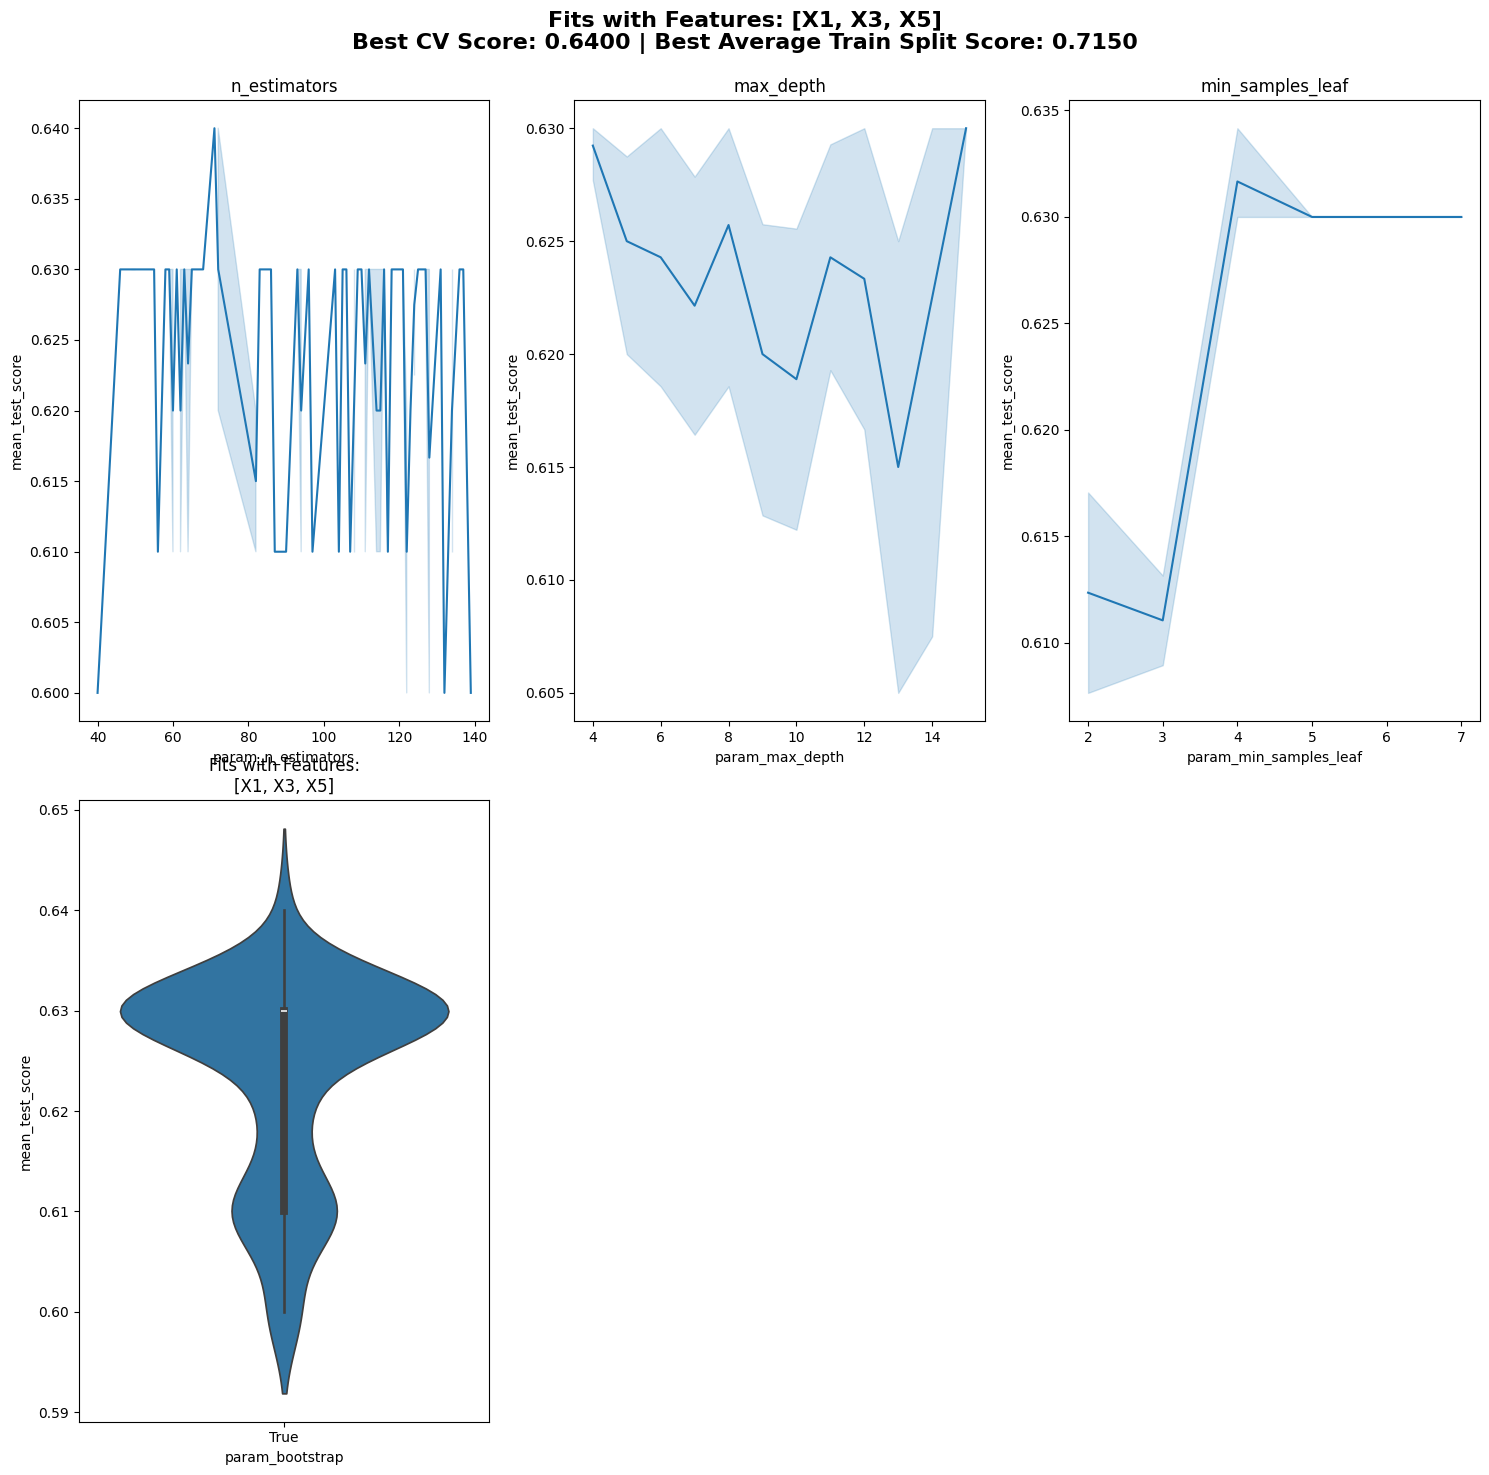



Feature Permutation Importance
______________________
X1: 0.227 +/- 0.065
X5: 0.096 +/- 0.063
X3: 0.023 +/- 0.049

______________________


e:\dev\workspace\Apziva\Project1\src\utils\tune_hyperparameters.py:292: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, i], X_test_subset, show=False)


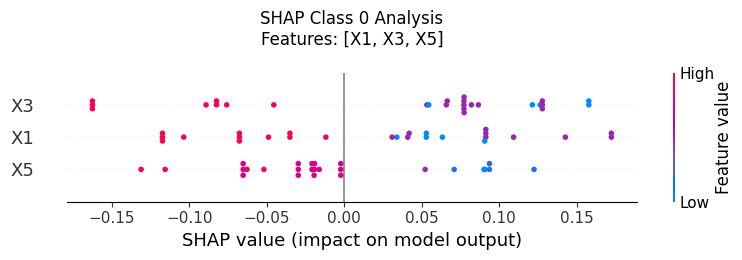

e:\dev\workspace\Apziva\Project1\src\utils\tune_hyperparameters.py:292: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, i], X_test_subset, show=False)


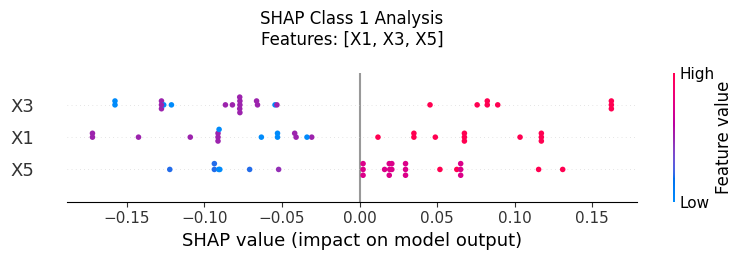

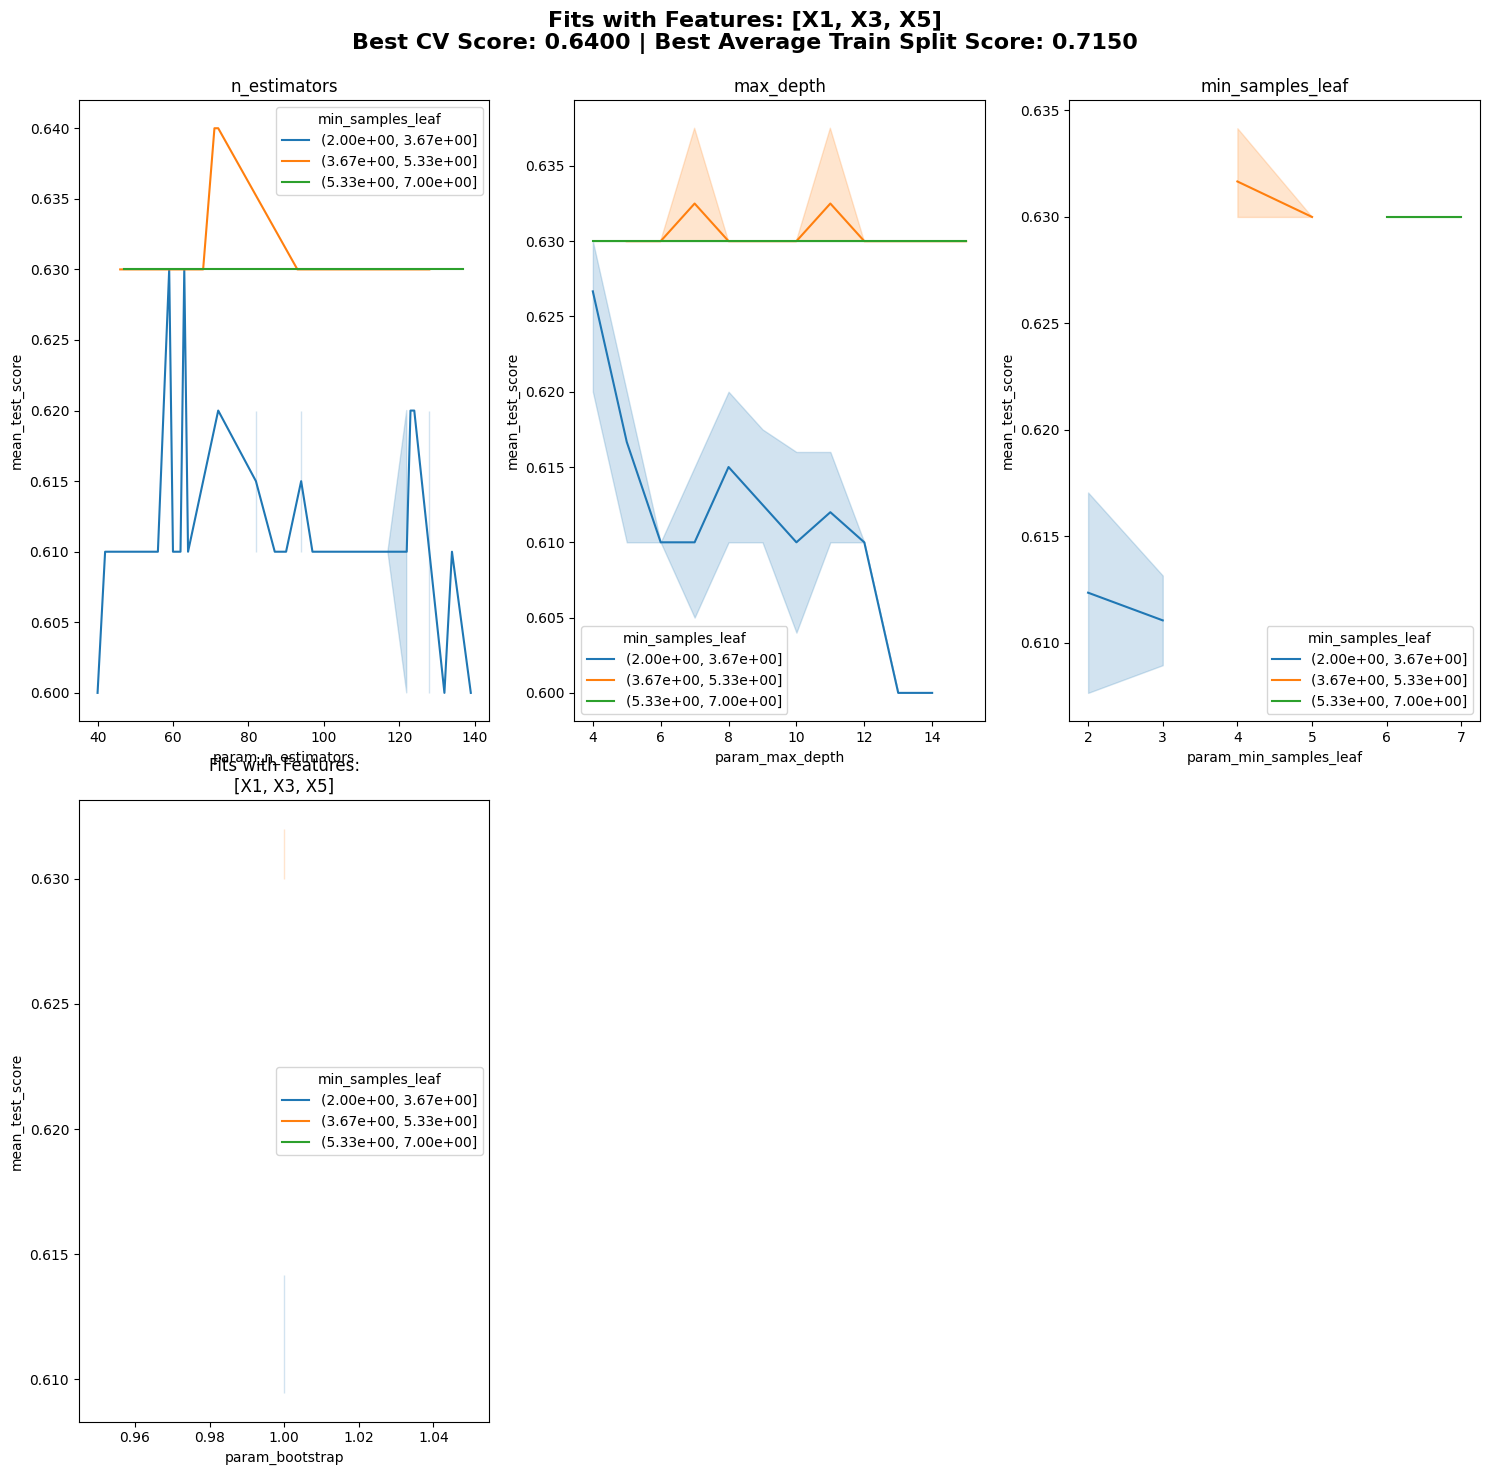

In [14]:
parameter_grid = {
    "n_estimators": randint(40, 140),
    "max_depth": randint(4,16),
    # "min_samples_split": randint(2, 21),
    "min_samples_leaf": randint(2, 8),
    # "max_features": ["sqrt", "log2", None],
    # "min_weight_fraction_leaf": uniform(0.0, 0.5),
    "bootstrap": [True],
}

model = RandomForestClassifier(random_state = random_state)
categorical_features = ["X1","X3","X5"]

t = ModelTuner(model, filename, "Y", categorical_features, random_state = random_state)

search = t.tune_model(hyperParameterGrid=parameter_grid, n_iter = 100,)
t.feature_permutation(search.best_params_)
t.shap_analysis(search.best_params_)
t.display_parameter_fits(search, parameter_grid, groupby="min_samples_leaf")

In [15]:
t.predict_test_split(search.best_params_)

0.7307692307692307

accuracy = 0.7307692307692307

In [16]:
import pandas as pd
pd.DataFrame(search.cv_results_).loc[search.best_index_]

mean_fit_time                                                      0.076794
std_fit_time                                                       0.000735
mean_score_time                                                    0.005914
std_score_time                                                     0.000136
param_bootstrap                                                        True
param_max_depth                                                          11
param_min_samples_leaf                                                    4
param_n_estimators                                                       71
params                    {'bootstrap': True, 'max_depth': 11, 'min_samp...
split0_test_score                                                       0.6
split1_test_score                                                      0.65
split2_test_score                                                       0.6
split3_test_score                                                       0.6
split4_test_

___

# An adaquate accuracy has been reached. Now time to save the model

___

In [17]:
t.save_model(filename="../../src/models/saved_models/RandomForest_01", hyperparams=t.last_search.best_params_, final=True, notes="CV: 0.64 ± 0.05831, trainScore: 0.7150, testScore1: 0.7307692307692307")